# Neural Membrane Dynamics: From Biophysics to Dynamical Systems

*A first-principles exploration of the Hodgkin-Huxley model*

## Why Model Neurons Mathematically?

The nervous system is arguably the most complex structure in the known universe. A single human brain contains roughly $10^{11}$ neurons, each forming thousands of synaptic connections. Yet the fundamental electrical event underlying all neural computation (the **action potential**) can be described by a system of just four ordinary differential equations. This remarkable compression of biological complexity into mathematical form is one of the great triumphs of 20th-century biophysics.

Mathematical models of neurons serve multiple purposes. First, they provide a **quantitative framework** for understanding how ionic currents flowing through protein channels in the cell membrane give rise to the rapid, all-or-nothing voltage spikes that carry information along nerve fibers. Without equations, we are limited to qualitative descriptions; with them, we can predict precisely how a neuron will respond to any given stimulus. Second, neural models reveal **universal dynamical principles** (bifurcations, limit cycles, excitability thresholds) that transcend the specific biological details and connect neuroscience to the broader theory of nonlinear dynamical systems.

Third, and perhaps most importantly, mathematical neuron models are the **building blocks of computational neuroscience**. From small circuits of a few neurons to large-scale brain simulations involving millions of units, every computational model of neural activity rests on some mathematical description of individual cells. Understanding the Hodgkin-Huxley model is therefore not merely an exercise in biophysics: it is the foundation upon which modern theoretical neuroscience is built.

### Historical Context

In the late 1940s and early 1950s, Alan Hodgkin and Andrew Huxley carried out a series of extraordinary experiments on the **giant axon of the Atlantic squid** (*Loligo*). The squid giant axon, with a diameter of up to 1 mm, was large enough to allow insertion of electrodes directly into the interior of the nerve fiber; a feat impossible with the much thinner axons of vertebrate neurons at the time.

Using the **voltage clamp technique**, Hodgkin and Huxley were able to hold the membrane potential at a fixed value and measure the ionic currents flowing through the membrane at that voltage. By systematically varying the clamp voltage and using ion substitution experiments (replacing external sodium with choline), they separated the total membrane current into its sodium, potassium, and leak components. They then fitted empirical equations to describe how the conductance of each ion channel depended on voltage and time.

The result, published in a landmark series of five papers in 1952, was a mathematical model that could **quantitatively reproduce** the shape, amplitude, duration, and propagation velocity of the action potential: all from first principles, without any free parameters adjusted after the fact. For this work, Hodgkin and Huxley were awarded the **Nobel Prize in Physiology or Medicine in 1963**.

### Roadmap

In this notebook, we will:

1. **Derive the electrical circuit model** of the neuronal membrane from physical principles
2. **Develop the Hodgkin-Huxley equations** step by step, motivating every term
3. **Simulate action potentials** and explore how they depend on stimulus parameters
4. **Analyze the ionic currents** underlying each phase of the action potential
5. **Investigate the dynamical systems structure**: fixed points, stability, and bifurcations
6. **Construct phase portraits** and nullcline diagrams
7. **Compute the frequency-current (f-I) relationship** and explore neural coding
8. **Compare with simplified models** such as the leaky integrate-and-fire neuron

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Allow imports from the src/ package
sys.path.insert(0, '../src')

from neural_dynamics import (
    alpha_n, beta_n, alpha_m, beta_m, alpha_h, beta_h,
    n_inf, m_inf, h_inf, tau_n, tau_m, tau_h,
    HH_DEFAULT_PARAMS,
    hh_rhs_parameterized, hh_initial_state,
    hh_solve_constant, hh_solve_current_array,
    solve_ode, make_hh_rhs,
)

print("All imports successful.")

All imports successful.


In [2]:
# Publication-quality matplotlib configuration
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'lines.linewidth': 2,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Consistent color scheme for the entire notebook
COLORS = {
    'Na': '#E74C3C',     # red: sodium
    'K': '#3498DB',      # blue: potassium
    'leak': '#95A5A6',   # gray: leak
    'Vm': '#2C3E50',     # dark: membrane potential
    'accent': '#8E44AD', # purple: accent for special curves
    'green': '#27AE60',  # green: auxiliary
}

print("Matplotlib configured for publication-quality figures.")

Matplotlib configured for publication-quality figures.


---

# 2. The Neuron as an Electrical Circuit

To understand how a neuron generates electrical signals, we must first understand the **physical properties of the cell membrane** and how they give rise to electrical behavior. In this section, we build up the equivalent circuit model of a small patch of neuronal membrane, deriving each component from first principles.

## 2.1 The Cell Membrane as a Capacitor

The neuronal cell membrane is a **lipid bilayer**: a thin sheet (approximately $d \approx 7\text{-}8 \; \text{nm}$ thick) composed of phospholipid molecules whose hydrophobic tails face inward, forming a nearly impermeable barrier to ions. On either side of this insulating layer lies an electrically conducting aqueous solution: the **intracellular fluid** (cytoplasm) and the **extracellular fluid**.

This arrangement (two conductors separated by an insulating dielectric) is precisely the definition of a **parallel-plate capacitor**. From elementary electrostatics, the capacitance of a parallel-plate capacitor with plate area $A$, plate separation $d$, and dielectric constant $\varepsilon$ is:

$$C = \varepsilon \frac{A}{d} = \varepsilon_0 \varepsilon_r \frac{A}{d}$$

where $\varepsilon_0 \approx 8.85 \times 10^{-12} \; \text{F/m}$ is the permittivity of free space and $\varepsilon_r \approx 2$ is the relative permittivity of the lipid core. Substituting typical values:

$$c_m = \frac{C}{A} = \frac{\varepsilon_0 \varepsilon_r}{d} \approx \frac{(8.85 \times 10^{-12})(2)}{7.5 \times 10^{-9}} \approx 2.4 \times 10^{-3} \; \text{F/m}^2 \approx 0.24 \; \mu\text{F/cm}^2$$

Experimentally, the specific membrane capacitance is measured to be:

$$\boxed{C_m \approx 1 \; \mu\text{F/cm}^2}$$

The discrepancy (roughly a factor of 4) arises because the effective dielectric constant of the full membrane (including polar head groups, bound water molecules, and membrane proteins) is higher than that of the pure lipid core. The value $C_m \approx 1 \; \mu\text{F/cm}^2$ is remarkably universal across cell types and organisms.

The charge stored on the membrane capacitor is $Q = C_m V_m$, where $V_m = V_\text{in} - V_\text{out}$ is the **membrane potential**. The capacitive current (current flowing to charge or discharge the capacitor) is therefore:

$$\boxed{I_C = C_m \frac{dV_m}{dt}}$$

This tells us that the membrane potential can change only when current flows onto or off of the membrane capacitor. This is the starting point for all electrical models of neurons.

## 2.2 Ion Channels as Conductances

While the lipid bilayer is an excellent insulator, the cell membrane is studded with **ion channel proteins**: large transmembrane proteins that form aqueous pores through which specific ions can flow. The key channel types for the action potential are:

- **Voltage-gated Na$^+$ channels**: selectively permeable to sodium ions, open rapidly upon depolarization
- **Voltage-gated K$^+$ channels**: selectively permeable to potassium ions, open more slowly upon depolarization
- **Leak channels**: always open, primarily permeable to K$^+$ and Cl$^-$, responsible for the resting potential

Each population of ion channels can be characterized by a **conductance** $g_\text{ion}$ (the inverse of resistance), measured in units of mS/cm$^2$ (millisiemens per square centimeter of membrane). The conductance represents how easily ions can flow through the channels: high conductance means many channels are open, low conductance means few are open.

The current through a given ion channel population obeys an **Ohmic** (linear) relationship:

$$\boxed{I_\text{ion} = g_\text{ion} \cdot (V_m - E_\text{ion})}$$

where $E_\text{ion}$ is the **reversal potential** (or equilibrium potential) of that ion species. The driving force $(V_m - E_\text{ion})$ is the difference between the actual membrane potential and the potential at which the net current through those channels would be zero. When $V_m = E_\text{ion}$, the electrical and chemical driving forces on the ion are exactly balanced, and no net current flows: hence the name "reversal potential."

The critical insight that distinguishes the Hodgkin-Huxley model from simpler models is that the conductances $g_\text{Na}$ and $g_\text{K}$ are **not constant**: they are functions of both voltage and time. Understanding how to describe this voltage- and time-dependence is the central challenge of the model, and we will address it in Section 3.

## 2.3 The Nernst Equation (Full Derivation)

Where does the reversal potential $E_\text{ion}$ come from? It arises from the fact that ion concentrations differ dramatically between the inside and outside of the cell. For example, K$^+$ is roughly 20 times more concentrated inside the cell than outside, while Na$^+$ is roughly 10 times more concentrated outside. These concentration gradients are maintained by metabolic pumps (primarily the Na$^+$/K$^+$-ATPase).

When a channel selective for a particular ion opens, two forces act on that ion:

1. **The chemical force** (diffusion): ions tend to flow down their concentration gradient, from high to low concentration.
2. **The electrical force** (drift): ions are charged particles and are attracted or repelled by the electric field across the membrane.

At equilibrium, these two forces balance exactly. Let us derive the voltage at which this occurs.

### Derivation from Thermodynamic First Principles

Consider a single ion species with valence $z$ (e.g., $z = +1$ for Na$^+$ and K$^+$, $z = -1$ for Cl$^-$). The **electrochemical potential** of this ion on each side of the membrane has two contributions:

$$\mu = \mu_\text{chemical} + \mu_\text{electrical}$$

The chemical potential of an ideal solute at concentration $[\text{ion}]$ is:

$$\mu_\text{chemical} = \mu^0 + RT \ln[\text{ion}]$$

where $R = 8.314 \; \text{J/(mol} \cdot \text{K)}$ is the gas constant, $T$ is absolute temperature, and $\mu^0$ is a reference chemical potential.

The electrical potential energy of one mole of ions with charge $z$ at voltage $V$ is:

$$\mu_\text{electrical} = zFV$$

where $F = 96{,}485 \; \text{C/mol}$ is Faraday's constant. Therefore the total electrochemical potential is:

$$\mu = \mu^0 + RT \ln[\text{ion}] + zFV$$

At **thermodynamic equilibrium**, the electrochemical potential must be equal on both sides of the membrane:

$$\mu_\text{out} = \mu_\text{in}$$

$$\mu^0 + RT \ln[\text{ion}]_\text{out} + zF V_\text{out} = \mu^0 + RT \ln[\text{ion}]_\text{in} + zF V_\text{in}$$

The reference potentials $\mu^0$ cancel. Rearranging to solve for the transmembrane potential $E_\text{ion} = V_\text{in} - V_\text{out}$:

$$zF(V_\text{in} - V_\text{out}) = RT \ln[\text{ion}]_\text{out} - RT \ln[\text{ion}]_\text{in}$$

$$E_\text{ion} = V_\text{in} - V_\text{out} = \frac{RT}{zF} \ln \frac{[\text{ion}]_\text{out}}{[\text{ion}]_\text{in}}$$

This is the **Nernst equation**:

$$\boxed{E_\text{ion} = \frac{RT}{zF} \ln \frac{[\text{ion}]_\text{out}}{[\text{ion}]_\text{in}}}$$

At body temperature ($T = 310 \; \text{K}$) or squid axon temperature ($T \approx 279 \; \text{K}$ for $6.3°\text{C}$), the prefactor $RT/F \approx 24\text{-}27 \; \text{mV}$ for monovalent ions. Using the ionic concentrations of the squid giant axon:

| Ion | $[\text{ion}]_\text{in}$ (mM) | $[\text{ion}]_\text{out}$ (mM) | $z$ | $E_\text{ion}$ (mV) |
|-----|------|------|---|------|
| K$^+$ | 400 | 20 | +1 | $\approx -77$ |
| Na$^+$ | 50 | 440 | +1 | $\approx +50$ |
| Cl$^-$ | 40 | 560 | $-1$ | $\approx -66$ |

The large difference between $E_\text{Na} \approx +50 \; \text{mV}$ and $E_\text{K} \approx -77 \; \text{mV}$ is what makes the action potential possible: the membrane can swing between these two "battery" voltages by selectively opening Na$^+$ or K$^+$ channels.

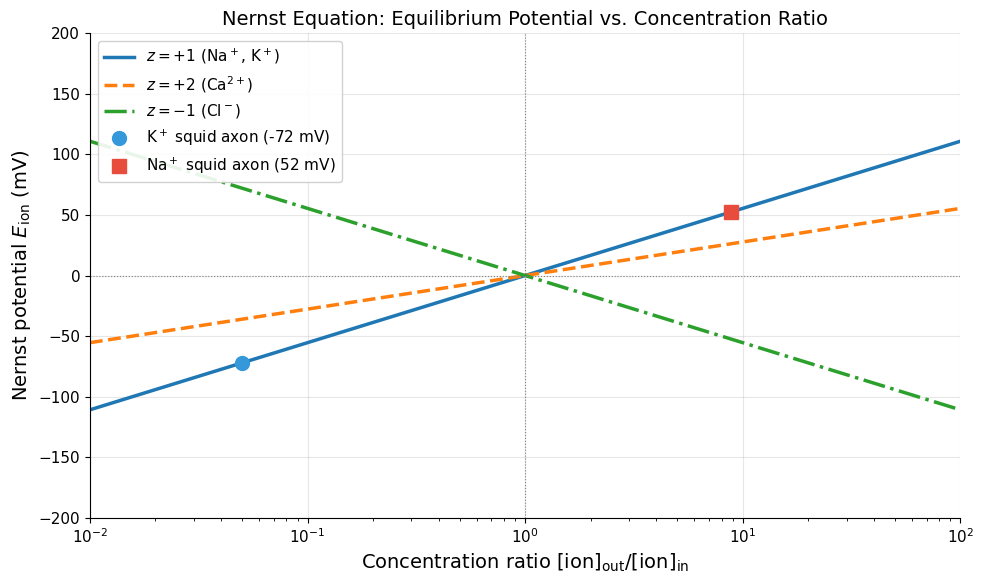

In [3]:
# Nernst equation: E_ion as a function of concentration ratio for different valences

R = 8.314    # J/(mol*K)
T = 279.45   # K (6.3°C, Hodgkin-Huxley experimental temperature)
F = 96485.0  # C/mol

# Concentration ratio [out]/[in]
ratio = np.logspace(-2, 2, 500) # from 0.01 to 100

fig, ax = plt.subplots(figsize=(10, 6))

for z, label, ls in [(1, '$z = +1$ (Na$^+$, K$^+$)', '-'),
                     (2, '$z = +2$ (Ca$^{2+}$)', '--'),
                     (-1, '$z = -1$ (Cl$^-$)', '-.')]:
    E = (R * T / (z * F)) * np.log(ratio) * 1000  # convert V to mV
    ax.plot(ratio, E, ls, label=label, linewidth=2.5)

# Mark the actual squid axon values
E_K = (R * T / F) * np.log(20 / 400) * 1000
E_Na = (R * T / F) * np.log(440 / 50) * 1000
ax.plot(20 / 400, E_K, 'o', color=COLORS['K'], markersize=10, zorder=5,
        label=f'K$^+$ squid axon ({E_K:.0f} mV)')
ax.plot(440 / 50, E_Na, 's', color=COLORS['Na'], markersize=10, zorder=5,
        label=f'Na$^+$ squid axon ({E_Na:.0f} mV)')

ax.set_xscale('log')
ax.set_xlabel('Concentration ratio $[\\mathrm{ion}]_{\\mathrm{out}} / [\\mathrm{ion}]_{\\mathrm{in}}$')
ax.set_ylabel('Nernst potential $E_{\\mathrm{ion}}$ (mV)')
ax.set_title('Nernst Equation: Equilibrium Potential vs. Concentration Ratio')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.axvline(1, color='gray', linewidth=0.8, linestyle=':')
ax.legend(loc='upper left', framealpha=0.9)
ax.set_ylim(-200, 200)
ax.set_xlim(0.01, 100)

plt.tight_layout()
plt.show()

## 2.4 The Goldman-Hodgkin-Katz Equation

The Nernst equation gives the equilibrium potential for a single ion species. But at rest, the membrane is permeable to **multiple ion species simultaneously**: primarily K$^+$, Na$^+$, and Cl$^-$. The resting membrane potential is therefore not equal to any single Nernst potential, but rather a weighted average that depends on the **relative permeabilities** of the membrane to each ion.

The **Goldman-Hodgkin-Katz (GHK) voltage equation** generalizes the Nernst equation to multiple ions. It is derived from the Nernst-Planck equation for electrodiffusion under the assumption of a constant electric field across the membrane (the "constant field" approximation). For Na$^+$, K$^+$, and Cl$^-$:

$$\boxed{V_m = \frac{RT}{F} \ln \frac{P_\text{K}[\text{K}^+]_\text{out} + P_\text{Na}[\text{Na}^+]_\text{out} + P_\text{Cl}[\text{Cl}^-]_\text{in}}{P_\text{K}[\text{K}^+]_\text{in} + P_\text{Na}[\text{Na}^+]_\text{in} + P_\text{Cl}[\text{Cl}^-]_\text{out}}}$$

where $P_\text{K}$, $P_\text{Na}$, $P_\text{Cl}$ are the membrane permeabilities to each ion. Note that chloride concentrations are "flipped" (inside in numerator, outside in denominator) because Cl$^-$ has negative valence.

At rest, the squid axon membrane is much more permeable to K$^+$ than to Na$^+$, with typical permeability ratios $P_\text{K} : P_\text{Na} : P_\text{Cl} \approx 1 : 0.04 : 0.45$. Substituting the squid axon concentrations:

$$V_\text{rest} \approx -65 \; \text{mV}$$

This value is close to $E_\text{K}$ (since K$^+$ permeability dominates at rest) but is pulled slightly positive by the small Na$^+$ permeability. During an action potential, when Na$^+$ channels open and $P_\text{Na}$ increases dramatically, the GHK equation predicts that $V_m$ will swing toward $E_\text{Na} \approx +50 \; \text{mV}$.

## 2.5 The Equivalent Circuit

We can now assemble the complete electrical equivalent circuit for a patch of neuronal membrane. The membrane consists of:

1. A **capacitor** $C_m$ (the lipid bilayer)
2. Three parallel **conductance branches**, one for each ion species, each consisting of a variable resistor (the channels) in series with a battery (the Nernst potential)
3. An optional **external current source** $I_\text{ext}$ (representing synaptic input or an experimentalist's electrode)

By **Kirchhoff's current law**, the total current flowing into the membrane patch must be zero. All current that enters as $I_\text{ext}$ must either charge the capacitor or flow out through the ion channels:

$$I_\text{ext} = I_C + I_\text{Na} + I_\text{K} + I_L$$

Substituting the expressions for each current:

$$I_\text{ext} = C_m \frac{dV_m}{dt} + g_\text{Na}(V_m - E_\text{Na}) + g_\text{K}(V_m - E_\text{K}) + g_L(V_m - E_L)$$

Rearranging to express the dynamics of the membrane potential:

$$\boxed{C_m \frac{dV_m}{dt} = -g_\text{Na}(V_m - E_\text{Na}) - g_\text{K}(V_m - E_\text{K}) - g_L(V_m - E_L) + I_\text{ext}}$$

**This is THE fundamental equation of the Hodgkin-Huxley model.** Everything that follows (the gating variables, the rate functions, the full system of ODEs) is devoted to specifying how the conductances $g_\text{Na}$ and $g_\text{K}$ depend on voltage and time. The leak conductance $g_L$ is constant (representing channels that are always open).

The physical content of this equation is transparent:
- The left side is the rate of change of charge on the membrane capacitor.
- The right side is the net current: external current minus the sum of all ionic currents.
- Each ionic current is proportional to its conductance times its driving force.
- The membrane potential $V_m$ evolves toward whichever reversal potential has the largest conductance at that moment.

With constant conductances, this equation describes a simple leaky integrator; the membrane potential exponentially relaxes toward a weighted average of the reversal potentials. The action potential emerges only when we allow $g_\text{Na}$ and $g_\text{K}$ to depend on voltage, creating a powerful positive feedback loop. This is the subject of the next section.

---

# 3. Deriving the Hodgkin-Huxley Equations

In Section 2 we established that the membrane potential obeys $C_m \, dV/dt = -\sum I_\text{ion} + I_\text{ext}$, with ionic currents of the form $I_\text{ion} = g_\text{ion}(V_m - E_\text{ion})$. The remaining challenge is to describe how the conductances $g_\text{Na}$ and $g_\text{K}$ depend on voltage and time. This is where Hodgkin and Huxley's experimental genius and mathematical creativity come together.

## 3.1 Voltage-Dependent Conductances

Hodgkin and Huxley's voltage clamp experiments revealed a crucial fact: **the membrane conductances are not constant.** When the membrane is depolarized (voltage stepped to a more positive value):

- The **Na$^+$ conductance** rises rapidly to a peak and then decays back toward zero, even though the voltage is held constant. This transient behavior reflects two distinct processes: fast **activation** (opening) followed by slower **inactivation** (a conformational change that blocks the open channel).
- The **K$^+$ conductance** rises more slowly to a sustained plateau and remains elevated as long as the depolarization is maintained. K$^+$ channels activate but do not inactivate on the timescale of the action potential.

These are the experimental signatures that the model must capture. The conductances are functions of both voltage (because the rate of opening/closing depends on $V_m$) and time (because the channels take time to respond to voltage changes).

## 3.2 Gating Variables

Hodgkin and Huxley's key insight was to decompose each conductance into the product of a **maximum conductance** $\bar{g}$ (when all channels are open) and one or more **gating variables** that represent the fraction of channels in the open state. Each gating variable takes values between 0 (all gates closed) and 1 (all gates open).

### The K$^+$ Channel: Four Identical Gates ($n^4$)

The K$^+$ conductance rises sigmoidally upon depolarization, not exponentially. Hodgkin and Huxley found that the time course of K$^+$ activation could be well described by the **fourth power** of a single gating variable $n$:

$$\boxed{g_\text{K}(t) = \bar{g}_\text{K} \cdot n(t)^4}$$

Why $n^4$? The physical picture is that the K$^+$ channel has **four identical, independent subunits** (gates), each of which must be in the "open" configuration for the channel to conduct. If each gate has probability $n$ of being open (independently), then the probability that all four are open simultaneously is $n^4$. This explains the sigmoidal rise: at early times, $n$ is increasing from a small value, and $n^4$ increases even more steeply. We now know from molecular biology that voltage-gated K$^+$ channels are indeed tetramers (four identical $\alpha$-subunits arranged around a central pore) a remarkable confirmation of HH's purely mathematical deduction.

### The Na$^+$ Channel: Three Activation Gates and One Inactivation Gate ($m^3 h$)

The Na$^+$ conductance has a more complex time course: it rises rapidly (activation) and then decays (inactivation), even at constant voltage. Hodgkin and Huxley modeled this by introducing **two types of gates**:

- **$m$**: an activation gate. Three identical $m$-gates must be open for the channel to conduct (similar logic to $n$ for K$^+$).
- **$h$**: an inactivation gate. This single gate must also be open. Unlike $m$, the $h$-gate is open at rest and *closes* upon depolarization.

The Na$^+$ conductance is therefore:

$$\boxed{g_\text{Na}(t) = \bar{g}_\text{Na} \cdot m(t)^3 \cdot h(t)}$$

Why $m^3 h$? The $m^3$ factor produces a rapid, sigmoidal rise in conductance (since $m$ activates quickly upon depolarization). The $h$ factor produces a slower decay (since $h$ decreases upon depolarization, eventually shutting off the channel). The product $m^3 h$ thus naturally produces a transient conductance that rises fast and falls slowly: exactly as observed experimentally.

Molecularly, we now know that Na$^+$ channels are single large proteins with four homologous domains (I-IV). Three of these contribute to activation (analogous to the three $m$-gates), while a cytoplasmic loop between domains III and IV acts as the "inactivation ball" that plugs the open channel (analogous to the $h$-gate).

## 3.3 First-Order Kinetics

Each gating variable $x \in \{n, m, h\}$ represents the probability that a single gate is in the open state. A gate can transition between two states:

$$\text{Closed} \underset{\beta_x(V)}{\overset{\alpha_x(V)}{\rightleftharpoons}} \text{Open}$$

where $\alpha_x(V)$ is the voltage-dependent **opening rate** (transition rate from closed to open, in ms$^{-1}$) and $\beta_x(V)$ is the **closing rate** (open to closed). If $x$ is the fraction of gates in the open state (and $1-x$ is the fraction closed), the rate of change is:

$$\boxed{\frac{dx}{dt} = \alpha_x(V)(1 - x) - \beta_x(V) \, x}$$

This is a **first-order linear ODE** in $x$ (for fixed $V$). The first term describes gates opening (proportional to the fraction that are closed, $1-x$), and the second describes gates closing (proportional to the fraction that are open, $x$).

### Equivalent Formulation: Steady-State and Time Constant

The rate equation can be rewritten in a more physically transparent form. Defining:

$$x_\infty(V) = \frac{\alpha_x(V)}{\alpha_x(V) + \beta_x(V)} \qquad \text{and} \qquad \tau_x(V) = \frac{1}{\alpha_x(V) + \beta_x(V)}$$

we can verify by substitution that the ODE becomes:

$$\boxed{\frac{dx}{dt} = \frac{x_\infty(V) - x}{\tau_x(V)}}$$

This form makes the physical meaning completely clear:

- $x_\infty(V)$ is the **steady-state value** of $x$ at voltage $V$. If the voltage is held constant, $x$ will exponentially relax toward $x_\infty(V)$.
- $\tau_x(V)$ is the **time constant** of this relaxation. A small $\tau_x$ means the gate responds quickly to voltage changes; a large $\tau_x$ means it responds slowly.

The solution at constant voltage is:

$$x(t) = x_\infty - (x_\infty - x_0) \, e^{-t/\tau_x}$$

where $x_0 = x(0)$ is the initial value. This exponential relaxation is the signature behavior of HH gating variables.

## 3.4 The Rate Functions

Hodgkin and Huxley determined the rate functions $\alpha_x(V)$ and $\beta_x(V)$ by fitting empirical expressions to their voltage clamp data. The original paper used a shifted voltage variable $v = V - V_\text{rest}$, but we present the equations in the **modern convention** where $V$ is the absolute membrane potential (rest $\approx -65 \; \text{mV}$):

### K$^+$ activation ($n$)

$$\alpha_n(V) = \frac{0.01 \, (V + 55)}{1 - \exp\!\big(-(V+55)/10\big)} \qquad \beta_n(V) = 0.125 \, \exp\!\big(-(V+65)/80\big)$$

### Na$^+$ activation ($m$)

$$\alpha_m(V) = \frac{0.1 \, (V + 40)}{1 - \exp\!\big(-(V+40)/10\big)} \qquad \beta_m(V) = 4 \, \exp\!\big(-(V+65)/18\big)$$

### Na$^+$ inactivation ($h$)

$$\alpha_h(V) = 0.07 \, \exp\!\big(-(V+65)/20\big) \qquad \beta_h(V) = \frac{1}{1 + \exp\!\big(-(V+35)/10\big)}$$

### Singularity Handling

Note that $\alpha_n$ and $\alpha_m$ have the form $f(V) = a(V - V_0) / (1 - e^{-(V-V_0)/k})$, which is indeterminate ($0/0$) at $V = V_0$ (i.e., at $V = -55 \; \text{mV}$ for $\alpha_n$ and $V = -40 \; \text{mV}$ for $\alpha_m$). Applying **L'Hopital's rule**:

$$\lim_{V \to V_0} \frac{a(V - V_0)}{1 - e^{-(V-V_0)/k}} = \lim_{V \to V_0} \frac{a}{e^{-(V-V_0)/k} / k} = a \cdot k$$

So $\alpha_n(-55) = 0.01 \times 10 = 0.1$ and $\alpha_m(-40) = 0.1 \times 10 = 1.0$. Our numerical implementation handles this by checking whether $|V - V_0| < \epsilon$ and returning the limiting value directly.

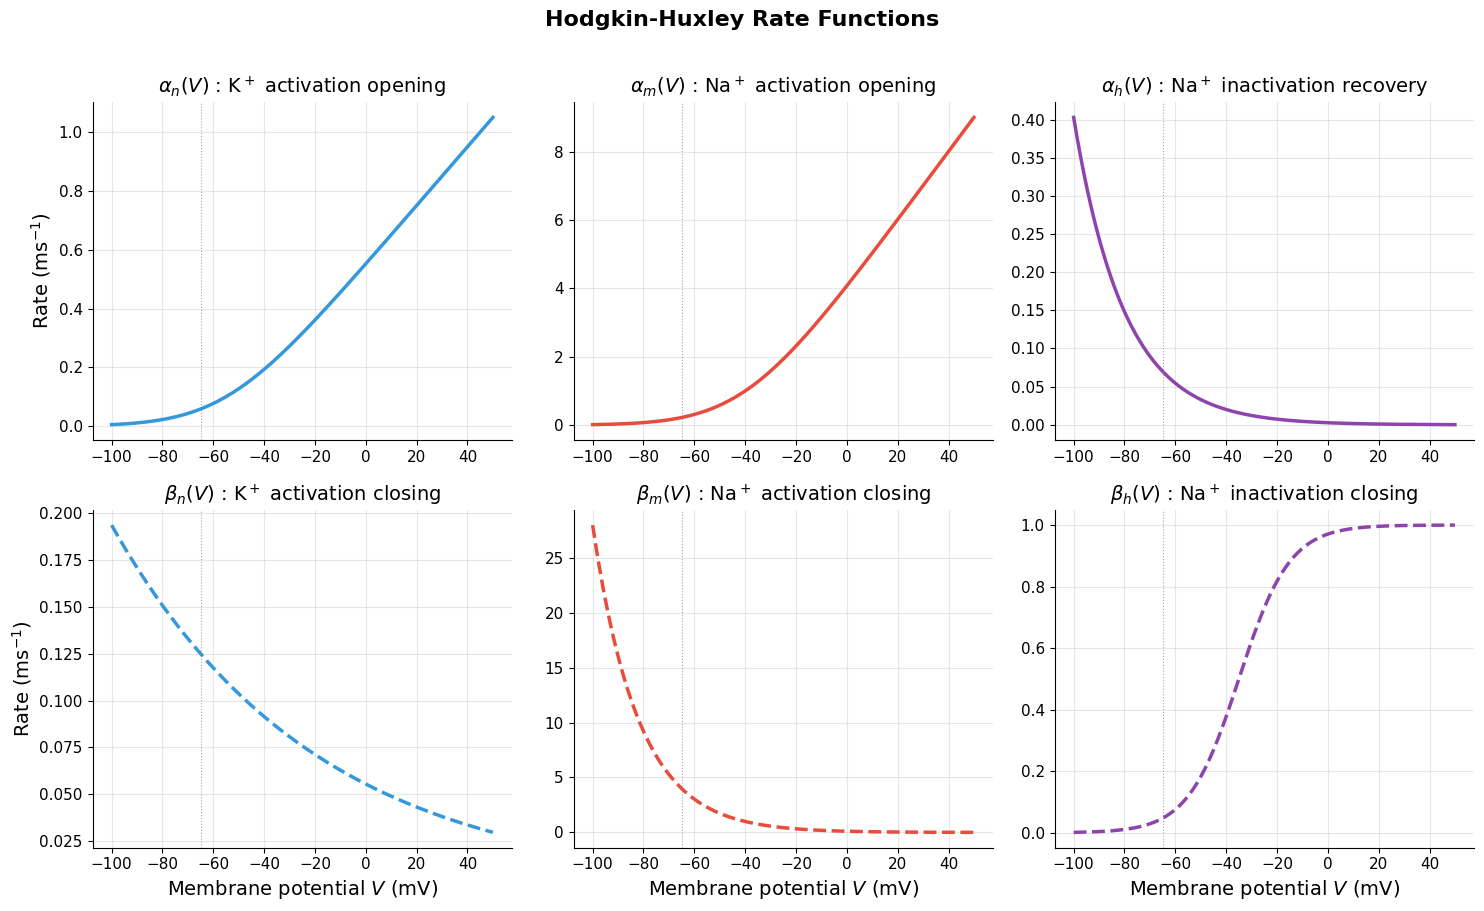

In [4]:
# Plot all 6 rate functions vs voltage (2x3 subplot grid)

V = np.linspace(-100, 50, 1000)

# Evaluate rate functions (vectorize since they are njit scalar functions)
an = np.array([alpha_n(v) for v in V])
bn = np.array([beta_n(v) for v in V])
am = np.array([alpha_m(v) for v in V])
bm = np.array([beta_m(v) for v in V])
ah = np.array([alpha_h(v) for v in V])
bh = np.array([beta_h(v) for v in V])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Row 1: alpha functions
axes[0, 0].plot(V, an, color=COLORS['K'], linewidth=2.5)
axes[0, 0].set_title(r'$\alpha_n(V)$ : K$^+$ activation opening')
axes[0, 0].set_ylabel('Rate (ms$^{-1}$)')

axes[0, 1].plot(V, am, color=COLORS['Na'], linewidth=2.5)
axes[0, 1].set_title(r'$\alpha_m(V)$ : Na$^+$ activation opening')

axes[0, 2].plot(V, ah, color=COLORS['accent'], linewidth=2.5)
axes[0, 2].set_title(r'$\alpha_h(V)$ : Na$^+$ inactivation recovery')

# Row 2: beta functions
axes[1, 0].plot(V, bn, color=COLORS['K'], linewidth=2.5, linestyle='--')
axes[1, 0].set_title(r'$\beta_n(V)$ : K$^+$ activation closing')
axes[1, 0].set_ylabel('Rate (ms$^{-1}$)')
axes[1, 0].set_xlabel('Membrane potential $V$ (mV)')

axes[1, 1].plot(V, bm, color=COLORS['Na'], linewidth=2.5, linestyle='--')
axes[1, 1].set_title(r'$\beta_m(V)$ : Na$^+$ activation closing')
axes[1, 1].set_xlabel('Membrane potential $V$ (mV)')

axes[1, 2].plot(V, bh, color=COLORS['accent'], linewidth=2.5, linestyle='--')
axes[1, 2].set_title(r'$\beta_h(V)$ : Na$^+$ inactivation closing')
axes[1, 2].set_xlabel('Membrane potential $V$ (mV)')

# Add resting potential line to all subplots
for ax in axes.flat:
    ax.axvline(-65, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)

fig.suptitle('Hodgkin-Huxley Rate Functions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

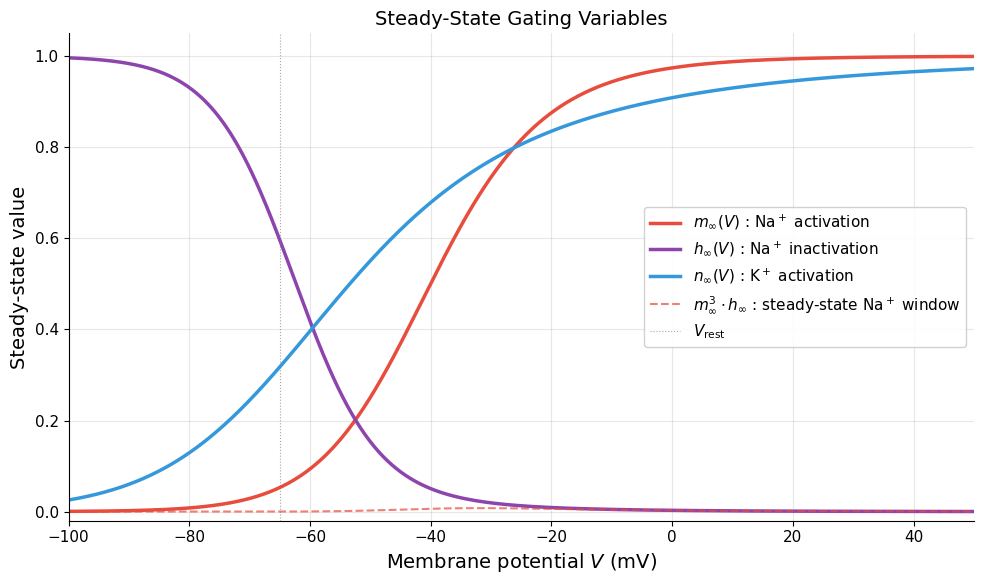

In [5]:
# Plot steady-state gating variables m_inf, h_inf, n_inf vs voltage

V = np.linspace(-100, 50, 1000)

m_ss = np.array([m_inf(v) for v in V])
h_ss = np.array([h_inf(v) for v in V])
n_ss = np.array([n_inf(v) for v in V])

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(V, m_ss, color=COLORS['Na'], linewidth=2.5, label=r'$m_\infty(V)$ : Na$^+$ activation')
ax.plot(V, h_ss, color=COLORS['accent'], linewidth=2.5, label=r'$h_\infty(V)$ : Na$^+$ inactivation')
ax.plot(V, n_ss, color=COLORS['K'], linewidth=2.5, label=r'$n_\infty(V)$ : K$^+$ activation')

# Product m_inf^3 * h_inf shows the steady-state Na+ conductance fraction
ax.plot(V, m_ss**3 * h_ss, color=COLORS['Na'], linewidth=1.5, linestyle='--',
        alpha=0.7, label=r'$m_\infty^3 \cdot h_\infty$ : steady-state Na$^+$ window')

ax.axvline(-65, color='gray', linewidth=0.8, linestyle=':', alpha=0.7, label='$V_{\\mathrm{rest}}$')
ax.set_xlabel('Membrane potential $V$ (mV)')
ax.set_ylabel('Steady-state value')
ax.set_title('Steady-State Gating Variables')
ax.legend(loc='center right', framealpha=0.9)
ax.set_ylim(-0.02, 1.05)
ax.set_xlim(-100, 50)

plt.tight_layout()
plt.show()

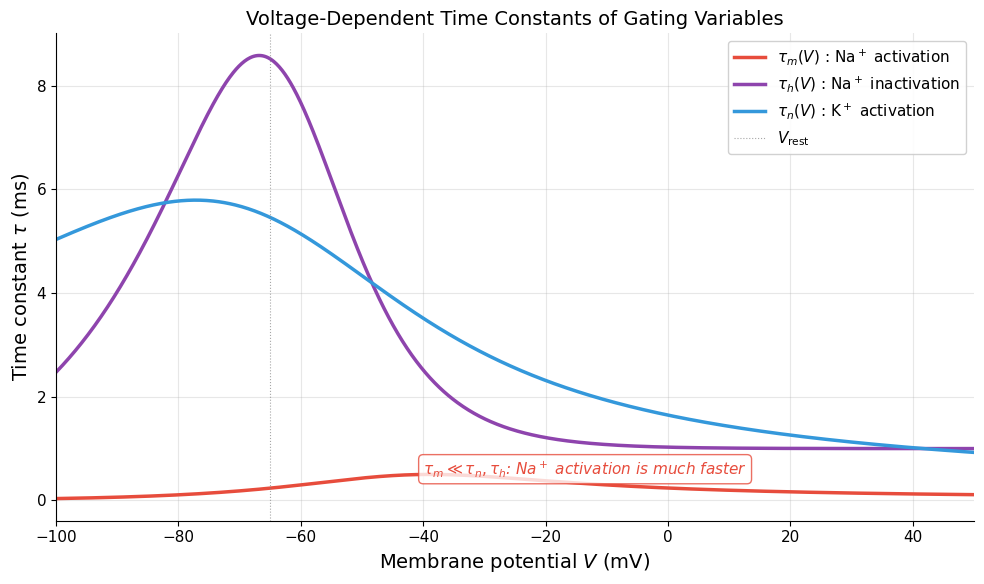

In [6]:
# Plot time constants tau_m, tau_h, tau_n vs voltage

V = np.linspace(-100, 50, 1000)

tm = np.array([tau_m(v) for v in V])
th = np.array([tau_h(v) for v in V])
tn = np.array([tau_n(v) for v in V])

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(V, tm, color=COLORS['Na'], linewidth=2.5,
        label=r'$\tau_m(V)$ : Na$^+$ activation')
ax.plot(V, th, color=COLORS['accent'], linewidth=2.5,
        label=r'$\tau_h(V)$ : Na$^+$ inactivation')
ax.plot(V, tn, color=COLORS['K'], linewidth=2.5,
        label=r'$\tau_n(V)$ : K$^+$ activation')

ax.axvline(-65, color='gray', linewidth=0.8, linestyle=':', alpha=0.7, label='$V_{\\mathrm{rest}}$')
ax.set_xlabel('Membrane potential $V$ (mV)')
ax.set_ylabel('Time constant $\\tau$ (ms)')
ax.set_title('Voltage-Dependent Time Constants of Gating Variables')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_xlim(-100, 50)

# Annotate the key observation
ax.annotate(r'$\tau_m \ll \tau_n, \tau_h$: Na$^+$ activation is much faster',
            xy=(-40, 0.5), fontsize=11, fontstyle='italic', color=COLORS['Na'],
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLORS['Na'], alpha=0.8))

plt.tight_layout()
plt.show()

## 3.5 The Complete Model

We can now assemble the full Hodgkin-Huxley model. The state of the membrane patch at any instant is described by four variables: the membrane potential $V$ and the three gating variables $n$, $m$, $h$. Their dynamics are governed by the following system of **four coupled ordinary differential equations**:

$$\boxed{\begin{aligned}
C_m \frac{dV}{dt} &= -\bar{g}_\text{Na} \, m^3 h \, (V - E_\text{Na}) - \bar{g}_\text{K} \, n^4 \, (V - E_\text{K}) - g_L \, (V - E_L) + I_\text{ext} \\[6pt]
\frac{dn}{dt} &= \alpha_n(V)(1 - n) - \beta_n(V) \, n \\[4pt]
\frac{dm}{dt} &= \alpha_m(V)(1 - m) - \beta_m(V) \, m \\[4pt]
\frac{dh}{dt} &= \alpha_h(V)(1 - h) - \beta_h(V) \, h
\end{aligned}}$$

The coupling is bidirectional and nonlinear: the gating variables affect $V$ through the conductances $m^3 h$ and $n^4$, while $V$ affects the gating variables through the rate functions $\alpha_x(V)$ and $\beta_x(V)$. This feedback is what produces the rich dynamics of the model, including the action potential.

### Parameter Table

The following are the **original parameters** from Hodgkin and Huxley (1952), measured at $6.3\,°\text{C}$:

| Parameter | Symbol | Value | Units |
|-----------|--------|-------|-------|
| Membrane capacitance | $C_m$ | 1.0 | $\mu\text{F/cm}^2$ |
| Max Na$^+$ conductance | $\bar{g}_\text{Na}$ | 120.0 | $\text{mS/cm}^2$ |
| Max K$^+$ conductance | $\bar{g}_\text{K}$ | 36.0 | $\text{mS/cm}^2$ |
| Leak conductance | $g_L$ | 0.3 | $\text{mS/cm}^2$ |
| Na$^+$ reversal potential | $E_\text{Na}$ | +50.0 | mV |
| K$^+$ reversal potential | $E_\text{K}$ | $-77.0$ | mV |
| Leak reversal potential | $E_L$ | $-54.4$ | mV |

Note the striking asymmetry: $\bar{g}_\text{Na}$ is more than three times larger than $\bar{g}_\text{K}$, which in turn is 120 times larger than $g_L$. When the Na$^+$ channels open fully, they can drive an enormous inward current that rapidly depolarizes the membrane.

These seven parameters, together with the six rate functions defined in Section 3.4, completely specify the model. In the next sections, we will simulate this system numerically and explore its remarkably rich dynamical behavior.

---

# 4. Numerical Implementation

We have derived a beautiful system of four coupled nonlinear ODEs, the Hodgkin-Huxley equations. But beauty alone does not produce action potentials. To actually *solve* these equations, we must turn to **numerical methods**.

Why can’t we simply write down an analytical solution? The answer lies in the **nonlinear coupling** between the equations. The membrane potential $V$ appears inside exponential functions (through the rate functions $\alpha_x(V)$ and $\beta_x(V)$), and these nonlinear functions of $V$ are multiplied by the gating variables, which themselves depend on $V$. There is no closed-form solution to this system. Even the existence and uniqueness of solutions must be established through the Picard-Lindelöf theorem, which guarantees local existence but tells us nothing about the solution’s form.

We therefore need **numerical integration**: we approximate the continuous ODEs by stepping forward in discrete time increments $\Delta t$, computing the state at each step from the state at the previous step. The art of numerical methods lies in choosing schemes that are accurate (small error per step), stable (errors don’t grow catastrophically), and efficient (few function evaluations per step).

A particular challenge for the HH system is **stiffness**. The fast Na$^+$ activation variable $m$ has a time constant as small as $\tau_m \approx 0.05 \; \text{ms}$ near the spike peak, while the slow K$^+$ activation $n$ has $\tau_n \approx 5 \; \text{ms}$; a ratio of 100:1. This disparity in timescales means that explicit methods must use time steps small enough to resolve the fastest dynamics, even during periods when only the slow dynamics are active. We will see how this affects the choice of method and step size.

## 4.1 The Euler Method

The simplest numerical method for ODEs is the **forward Euler method**, derived directly from the Taylor expansion of the solution. Suppose we know the state $\mathbf{y}(t)$ and wish to approximate $\mathbf{y}(t + \Delta t)$. Expanding in a Taylor series:

$$\mathbf{y}(t + \Delta t) = \mathbf{y}(t) + \Delta t \, \mathbf{y}'(t) + \frac{\Delta t^2}{2} \, \mathbf{y}''(t) + \mathcal{O}(\Delta t^3)$$

Since the ODE tells us that $\mathbf{y}'(t) = \mathbf{f}(t, \mathbf{y}(t))$, we can drop all terms of order $\Delta t^2$ and higher to obtain the **Euler approximation**:

$$\boxed{\mathbf{y}_{n+1} = \mathbf{y}_n + \Delta t \, \mathbf{f}(t_n, \mathbf{y}_n)}$$

### Error Analysis

The **local truncation error** (error per step, assuming exact input) is the first neglected term in the Taylor series:

$$e_\text{local} = \frac{\Delta t^2}{2} \, \mathbf{y}''(\xi) = \mathcal{O}(\Delta t^2)$$

for some $\xi \in [t_n, t_{n+1}]$ (by the mean value theorem). Over a total integration time $T$, we take $N = T / \Delta t$ steps, so the **global error** accumulates as:

$$e_\text{global} \leq N \cdot e_\text{local} = \frac{T}{\Delta t} \cdot \mathcal{O}(\Delta t^2) = \mathcal{O}(\Delta t)$$

The Euler method is therefore a **first-order method**: halving the step size halves the global error (but doubles the computational cost).

### Stability Considerations

For the HH system, the Euler method requires $\Delta t \lesssim 0.01 \; \text{ms}$ to maintain stability, primarily because of the fast Na$^+$ activation dynamics. With a time constant $\tau_m \approx 0.05 \; \text{ms}$, the stability condition $\Delta t < 2\tau_m$ gives $\Delta t < 0.1 \; \text{ms}$, and in practice a safety margin is needed. This is acceptable for short simulations but becomes expensive for long runs.

## 4.2 The 4th-Order Runge-Kutta Method (RK4)

Can we achieve higher accuracy without computing higher derivatives of $\mathbf{f}$? The **Runge-Kutta family** of methods answers this question affirmatively: instead of evaluating $\mathbf{f}$ at a single point (as in Euler), we evaluate it at **multiple carefully chosen points** within the interval $[t_n, t_n + \Delta t]$ and combine the results.

The most widely used member of this family is the **classical 4th-order Runge-Kutta method** (RK4). It computes four "slope estimates":

$$\begin{aligned}
\mathbf{k}_1 &= \mathbf{f}(t_n, \, \mathbf{y}_n) \\
\mathbf{k}_2 &= \mathbf{f}\!\left(t_n + \tfrac{\Delta t}{2}, \, \mathbf{y}_n + \tfrac{\Delta t}{2} \, \mathbf{k}_1\right) \\
\mathbf{k}_3 &= \mathbf{f}\!\left(t_n + \tfrac{\Delta t}{2}, \, \mathbf{y}_n + \tfrac{\Delta t}{2} \, \mathbf{k}_2\right) \\
\mathbf{k}_4 &= \mathbf{f}\!\left(t_n + \Delta t, \, \mathbf{y}_n + \Delta t \, \mathbf{k}_3\right)
\end{aligned}$$

and then advances the solution using their weighted average:

$$\boxed{\mathbf{y}_{n+1} = \mathbf{y}_n + \frac{\Delta t}{6}\left(\mathbf{k}_1 + 2\mathbf{k}_2 + 2\mathbf{k}_3 + \mathbf{k}_4\right)}$$

### Understanding Each Slope

The intuition behind the four slopes is as follows:

- $\mathbf{k}_1$: the slope at the **beginning** of the interval (same as Euler)
- $\mathbf{k}_2$: the slope at the **midpoint**, using an Euler half-step with slope $\mathbf{k}_1$ to predict the midpoint state. This is a first correction: we use the initial slope to estimate where we’ll be at the midpoint, then evaluate the slope there.
- $\mathbf{k}_3$: the slope at the **midpoint** again, but now using $\mathbf{k}_2$ (the corrected midpoint slope) for the half-step prediction. This is a second correction: we refine our midpoint estimate.
- $\mathbf{k}_4$: the slope at the **endpoint**, using a full step with slope $\mathbf{k}_3$.

### The 1:2:2:1 Weighting and Connection to Simpson’s Rule

The weights $\frac{1}{6}(1, 2, 2, 1)$ are not arbitrary. They correspond to **Simpson’s rule** for numerical integration. Recall that integrating $\mathbf{y}' = \mathbf{f}$ from $t_n$ to $t_n + \Delta t$ gives:

$$\mathbf{y}(t_n + \Delta t) - \mathbf{y}(t_n) = \int_{t_n}^{t_n + \Delta t} \mathbf{f}(\tau, \mathbf{y}(\tau)) \, d\tau$$

Simpson’s rule approximates an integral using values at the endpoints and midpoint with weights $\frac{\Delta t}{6}(1, 4, 1)$. The RK4 weights $\frac{\Delta t}{6}(1, 2, 2, 1)$ arise because the midpoint is sampled *twice* (as $\mathbf{k}_2$ and $\mathbf{k}_3$), splitting the weight of 4 into $2 + 2$.

### Error Analysis

The local truncation error of RK4 is $\mathcal{O}(\Delta t^5)$, and the global error is:

$$e_\text{global} = \mathcal{O}(\Delta t^4)$$

This is a dramatic improvement over Euler. Halving the step size reduces the error by a factor of $2^4 = 16$, at a cost of only doubling the number of steps (each step requires 4 function evaluations instead of 1, so the total cost increases by a factor of 8, but the error drops by 16). For the HH system, RK4 with $\Delta t = 0.01 \; \text{ms}$ gives results accurate to $\sim 10^{-8}$, far more than sufficient for any practical purpose.

## 4.3 Numba JIT Compilation

Python’s flexibility comes at a cost: as an interpreted language, every arithmetic operation incurs significant overhead from type checking, dynamic dispatch, and memory management. For a tight numerical loop (stepping an ODE forward in time for tens of thousands of iterations) this overhead can slow execution by a factor of 100 or more compared to compiled languages like C or Fortran.

**Numba** solves this problem by providing a **just-in-time (JIT) compiler** that translates Python functions directly into optimized machine code using the LLVM compiler framework. By adding the `@nb.njit` decorator (“nopython JIT”), we tell Numba to compile the function without any Python interpreter involvement: all operations are translated to native machine instructions, types are inferred at compile time, and the result runs at speeds comparable to hand-written C code.

The `@nb.njit` mode imposes restrictions: no Python objects (lists, dicts, classes), no dynamic typing, and limited library support. But for numerical code using NumPy arrays and scalar arithmetic (exactly the kind of code in an ODE integrator) these restrictions are easily met, and the payoff is enormous.

In our `neural_dynamics` package, every performance-critical function is decorated with `@nb.njit`:
- The HH rate functions (`alpha_n`, `beta_n`, etc.)
- The ODE right-hand side (`hh_rhs_parameterized`)
- The Euler and RK4 stepping functions (`euler_step`, `rk4_step`)
- The integration loop (`_solve_euler`, `_solve_rk4`)

Let us quantify the speedup with a concrete benchmark.

In [7]:
# Benchmark: Pure Python vs. Numba-compiled Euler integration
import time

# Simple test ODE: exponential decay dy/dt = -y, y(0) = 1
# Analytical solution: y(t) = exp(-t)

# --- Pure Python implementation (no Numba) ---
def euler_pure_python(y0, dt, n_steps):
    """Forward Euler for dy/dt = -y, pure Python."""
    y = y0
    for _ in range(n_steps):
        y = y + dt * (-y)
    return y

# --- Numba-compiled implementation ---
import numba as nb

@nb.njit
def euler_numba(y0, dt, n_steps):
    """Forward Euler for dy/dt = -y, Numba-compiled."""
    y = y0
    for _ in range(n_steps):
        y = y + dt * (-y)
    return y

# Parameters
dt = 0.001
n_steps = int(1.0 / dt) # 1 second of integration = 1000 steps
y0 = 1.0

# Warm up the Numba JIT compiler (first call triggers compilation)
_ = euler_numba(y0, dt, 10)

# Run many repetitions for reliable timing
n_reps = 2000

# Time pure Python
t_start = time.perf_counter()
for _ in range(n_reps):
    result_python = euler_pure_python(y0, dt, n_steps)
t_python = (time.perf_counter() - t_start) / n_reps

# Time Numba
t_start = time.perf_counter()
for _ in range(n_reps):
    result_numba = euler_numba(y0, dt, n_steps)
t_numba = (time.perf_counter() - t_start) / n_reps

# Verify correctness
exact = np.exp(-1.0)
print(f"Analytical solution:  y(1) = {exact:.10f}")
print(f"Pure Python result:   y(1) = {result_python:.10f}")
print(f"Numba result:         y(1) = {result_numba:.10f}")
print()
print(f"Pure Python time:     {t_python*1e6:.1f} \u00b5s")
print(f"Numba time:           {t_numba*1e6:.1f} \u00b5s")
print(f"Speedup:              {t_python/t_numba:.0f}x")

Analytical solution:  y(1) = 0.3678794412
Pure Python result:   y(1) = 0.3676954248
Numba result:         y(1) = 0.3676954248

Pure Python time:     27.3 µs
Numba time:           1.6 µs
Speedup:              17x


## 4.4 Validation: Reproducing Hodgkin & Huxley’s Results

Before exploring the model’s dynamics, we must first verify that our numerical implementation is correct. The gold standard is to reproduce the results from the original 1952 paper: specifically, the shape, amplitude, and duration of the action potential in response to a brief current stimulus.

We inject a **step current pulse** of $10 \; \mu\text{A/cm}^2$ for 1 ms into a resting membrane. If our implementation is correct, we should observe:

1. A rapid **depolarization** from the resting potential ($\approx -65 \; \text{mV}$) to a peak near $+40 \; \text{mV}$
2. A swift **repolarization** driven by K$^+$ channel opening and Na$^+$ channel inactivation
3. An **undershoot** (hyperpolarization) below the resting potential, caused by the lingering K$^+$ conductance
4. A slow return to rest as the K$^+$ channels close

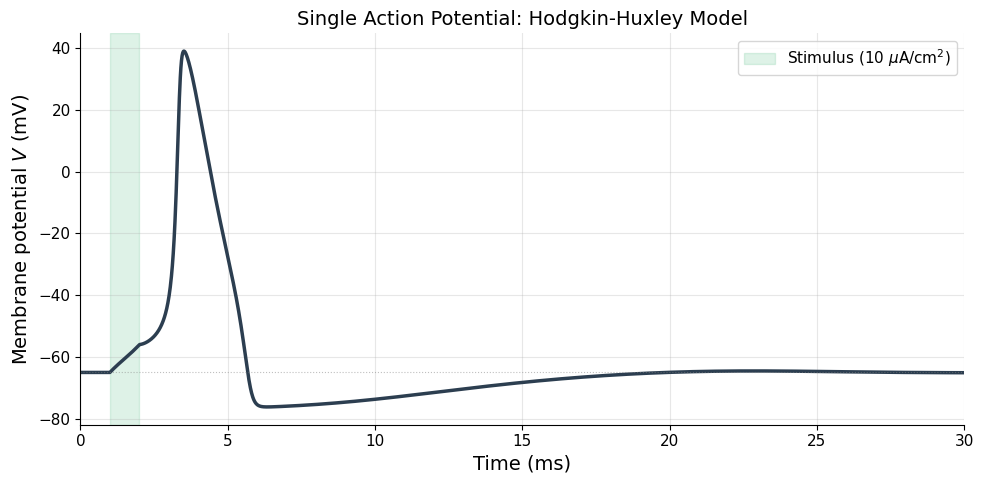

Peak voltage:    39.1 mV
Minimum voltage: -76.2 mV
Resting potential: -65.0 mV


In [8]:
# Simulate a single action potential with a 1 ms current pulse

dt_sim = 0.01  # ms
t_end_sim = 30.0  # ms
n_steps = int(t_end_sim / dt_sim)

# Build step current: 10 uA/cm2 for t in [1, 2] ms
I_ext = np.zeros(n_steps)
I_ext[int(1.0 / dt_sim):int(2.0 / dt_sim)] = 10.0

t, y = hh_solve_current_array(I_ext, dt_sim)

# Extract state variables
V = y[:, 0]
n_var = y[:, 1]
m_var = y[:, 2]
h_var = y[:, 3]

# Plot the action potential
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, V, color=COLORS['Vm'], linewidth=2.5)
ax.axhline(-65, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)

# Mark the stimulus period
ax.axvspan(1.0, 2.0, alpha=0.15, color=COLORS['green'],
           label=r'Stimulus (10 $\mu$A/cm$^2$)')

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Membrane potential $V$ (mV)')
ax.set_title('Single Action Potential: Hodgkin-Huxley Model')
ax.set_xlim(0, 30)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"Peak voltage:    {V.max():.1f} mV")
print(f"Minimum voltage: {V.min():.1f} mV")
print(f"Resting potential: {V[0]:.1f} mV")

C:\Users\jorge.delarosa\AppData\Local\Temp\ipykernel_38508\2590865348.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


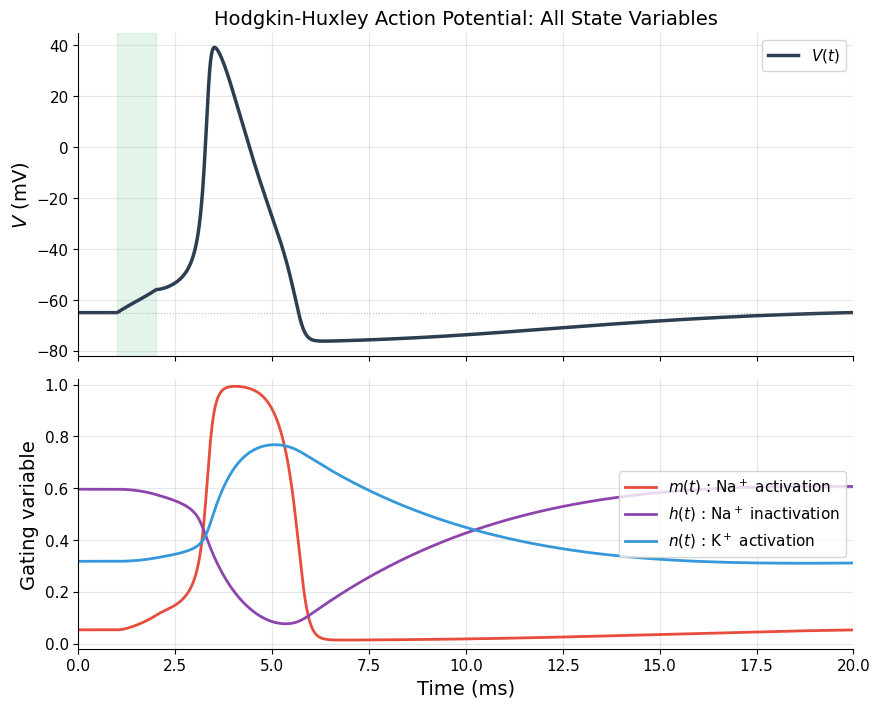

In [9]:
# All four state variables during the action potential

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                         gridspec_kw={'height_ratios': [1.2, 1], 'hspace': 0.08})

# Top panel: membrane potential
axes[0].plot(t, V, color=COLORS['Vm'], linewidth=2.5, label='$V(t)$')
axes[0].axhline(-65, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
axes[0].axvspan(1.0, 2.0, alpha=0.12, color=COLORS['green'])
axes[0].set_ylabel('$V$ (mV)')
axes[0].set_title('Hodgkin-Huxley Action Potential: All State Variables')
axes[0].legend(loc='upper right')
axes[0].set_xlim(0, 20)

# Bottom panel: gating variables
axes[1].plot(t, m_var, color=COLORS['Na'], linewidth=2,
             label='$m(t)$ : Na$^+$ activation')
axes[1].plot(t, h_var, color=COLORS['accent'], linewidth=2,
             label='$h(t)$ : Na$^+$ inactivation')
axes[1].plot(t, n_var, color=COLORS['K'], linewidth=2,
             label='$n(t)$ : K$^+$ activation')

axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Gating variable')
axes[1].legend(loc='right')
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_xlim(0, 20)

plt.tight_layout()
plt.show()

**Validation against the original paper.** The waveform above closely matches the classic action potential shape from Hodgkin & Huxley (1952), Figure 12. Key features reproduced:

- **Peak amplitude** $\approx +40 \; \text{mV}$, approaching $E_\text{Na} = +50 \; \text{mV}$
- **Spike duration** $\approx 1.5 \; \text{ms}$ (measured at half-maximum amplitude)
- **Undershoot** to $\approx -80 \; \text{mV}$, transiently exceeding $E_\text{K} = -77 \; \text{mV}$ due to the slow deactivation of K$^+$ channels
- **Temporal ordering** of gating variables: $m$ rises first (fast Na$^+$ activation), then $h$ falls (Na$^+$ inactivation) and $n$ rises (K$^+$ activation)

The gating variable dynamics reveal the **biophysical mechanism** of the action potential:
1. The stimulus depolarizes the membrane past threshold
2. $m$ gates open rapidly $\rightarrow$ Na$^+$ influx $\rightarrow$ positive feedback (more depolarization $\rightarrow$ more $m$ opening)
3. $h$ gates close (slower) $\rightarrow$ Na$^+$ channels inactivate, terminating the inward current
4. $n$ gates open (slow) $\rightarrow$ K$^+$ efflux $\rightarrow$ repolarization and undershoot
5. $n$ gates slowly close, $h$ gates slowly recover $\rightarrow$ return to rest

---

# 5. Simulating Neural Dynamics

Having validated our implementation, we can now use it as a *computational microscope* to explore the rich dynamical behavior of the Hodgkin-Huxley model. We will dissect the action potential into its constituent ionic currents, probe the threshold behavior that makes neural signaling digital, investigate the refractory periods that limit firing rates, and map out how the neuron encodes stimulus intensity into spike frequency.

## 5.1 Anatomy of an Action Potential

The action potential is not a single event but a sequence of **distinct biophysical phases**, each dominated by a different ionic current. By computing the individual currents $I_\text{Na}$, $I_\text{K}$, and $I_L$ from the simulation data, we can precisely identify which current drives each phase of the voltage waveform.

C:\Users\jorge.delarosa\AppData\Local\Temp\ipykernel_38508\3252343755.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


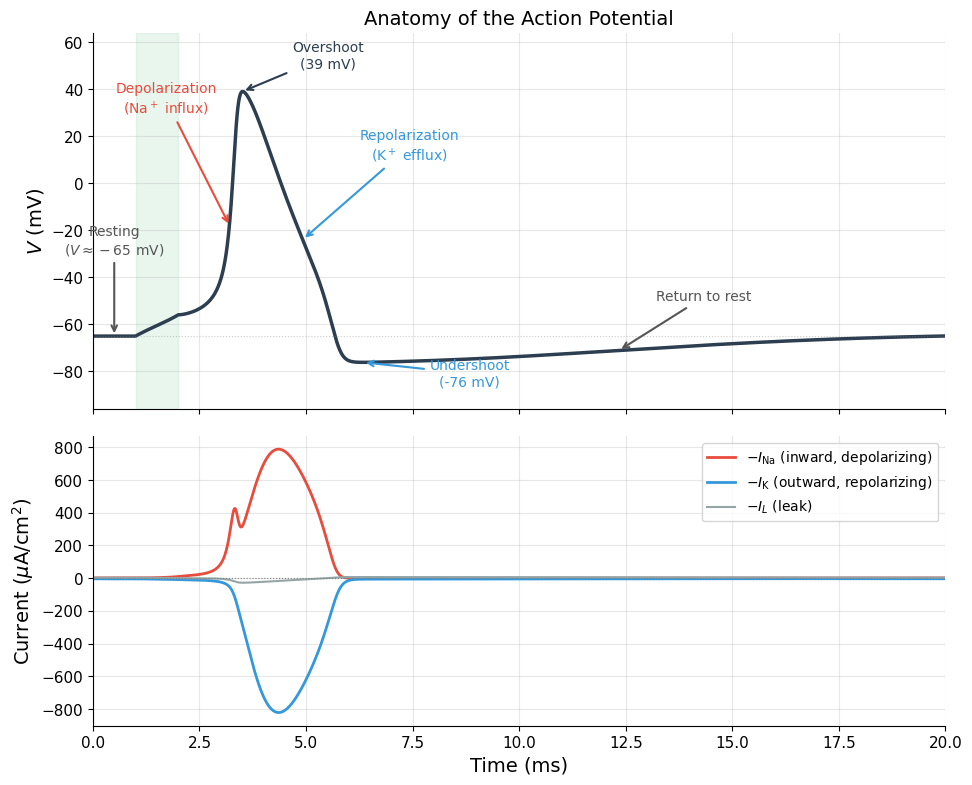

In [10]:
# Detailed anatomy of the action potential with phase annotations

# Compute ionic currents from the state variables
params = HH_DEFAULT_PARAMS
C_m, g_Na_max, g_K_max, g_L_val, E_Na, E_K, E_L = params

I_Na = g_Na_max * m_var**3 * h_var * (V - E_Na)
I_K  = g_K_max * n_var**4 * (V - E_K)
I_L_arr = g_L_val * (V - E_L)

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw={'height_ratios': [1.3, 1], 'hspace': 0.08})

# --- Top panel: Membrane potential with phase annotations ---
ax = axes[0]
ax.plot(t, V, color=COLORS['Vm'], linewidth=2.5)
ax.axhline(-65, color='gray', linewidth=0.8, linestyle=':', alpha=0.4)
ax.axvspan(1.0, 2.0, alpha=0.1, color=COLORS['green'])
ax.set_ylabel('$V$ (mV)')
ax.set_title('Anatomy of the Action Potential')

# Find key time points for annotations
idx_peak = np.argmax(V)
t_peak = t[idx_peak]
idx_trough = idx_peak + np.argmin(V[idx_peak:])
t_trough = t[idx_trough]

# Resting phase
ax.annotate('Resting\n($V \\approx -65$ mV)',
            xy=(0.5, V[0]), xytext=(0.5, -30),
            fontsize=10, ha='center', color='#555555',
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))

# Depolarization (Na+ influx)
t_rise = t_peak - 0.3
idx_rise = min(int(t_rise / 0.01), len(V) - 1)
ax.annotate('Depolarization\n(Na$^+$ influx)',
            xy=(t_rise, V[idx_rise]), xytext=(t_rise - 1.5, 30),
            fontsize=10, ha='center', color=COLORS['Na'],
            arrowprops=dict(arrowstyle='->', color=COLORS['Na'], lw=1.5))

# Overshoot
ax.annotate(f'Overshoot\n({V.max():.0f} mV)',
            xy=(t_peak, V.max()), xytext=(t_peak + 2.0, V.max() + 10),
            fontsize=10, ha='center', color=COLORS['Vm'],
            arrowprops=dict(arrowstyle='->', color=COLORS['Vm'], lw=1.5))

# Repolarization (K+ efflux)
t_repol = (t_peak + t_trough) / 2
idx_repol = min(int(t_repol / 0.01), len(V) - 1)
ax.annotate('Repolarization\n(K$^+$ efflux)',
            xy=(t_repol, V[idx_repol]), xytext=(t_repol + 2.5, 10),
            fontsize=10, ha='center', color=COLORS['K'],
            arrowprops=dict(arrowstyle='->', color=COLORS['K'], lw=1.5))

# Undershoot
ax.annotate(f'Undershoot\n({V.min():.0f} mV)',
            xy=(t_trough, V.min()), xytext=(t_trough + 2.5, V.min() - 10),
            fontsize=10, ha='center', color=COLORS['K'],
            arrowprops=dict(arrowstyle='->', color=COLORS['K'], lw=1.5))

# Return to rest
t_return = t_trough + 6
idx_return = min(int(t_return / 0.01), len(V) - 1)
ax.annotate('Return to rest',
            xy=(t_return, V[idx_return]),
            xytext=(t_return + 2, -50),
            fontsize=10, ha='center', color='#555555',
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))

ax.set_xlim(0, 20)
ax.set_ylim(V.min() - 20, V.max() + 25)

# --- Bottom panel: Ionic currents ---
ax2 = axes[1]
ax2.plot(t, -I_Na, color=COLORS['Na'], linewidth=2,
         label='$-I_{\\mathrm{Na}}$ (inward, depolarizing)')
ax2.plot(t, -I_K, color=COLORS['K'], linewidth=2,
         label='$-I_{\\mathrm{K}}$ (outward, repolarizing)')
ax2.plot(t, -I_L_arr, color=COLORS['leak'], linewidth=1.5,
         label='$-I_L$ (leak)')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle=':')

ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Current ($\\mu$A/cm$^2$)')
ax2.legend(loc='upper right', fontsize=10)
ax2.set_xlim(0, 20)

plt.tight_layout()
plt.show()

## 5.2 Threshold Behavior

One of the most striking features of the action potential is its **all-or-none** character. A stimulus that is too weak produces only a small, passive depolarization that decays back to rest. But once the stimulus exceeds a critical **threshold**, the full action potential is triggered with the same amplitude regardless of how far above threshold the stimulus is.

This threshold arises from the positive feedback loop in Na$^+$ activation: depolarization opens Na$^+$ channels $\rightarrow$ Na$^+$ influx $\rightarrow$ further depolarization. Below threshold, the outward leak and K$^+$ currents are strong enough to counteract the Na$^+$ current and pull the membrane back to rest. Above threshold, the Na$^+$ current wins, and the regenerative cycle drives the membrane to the peak of the spike.

Let us visualize this by injecting current pulses of increasing amplitude.

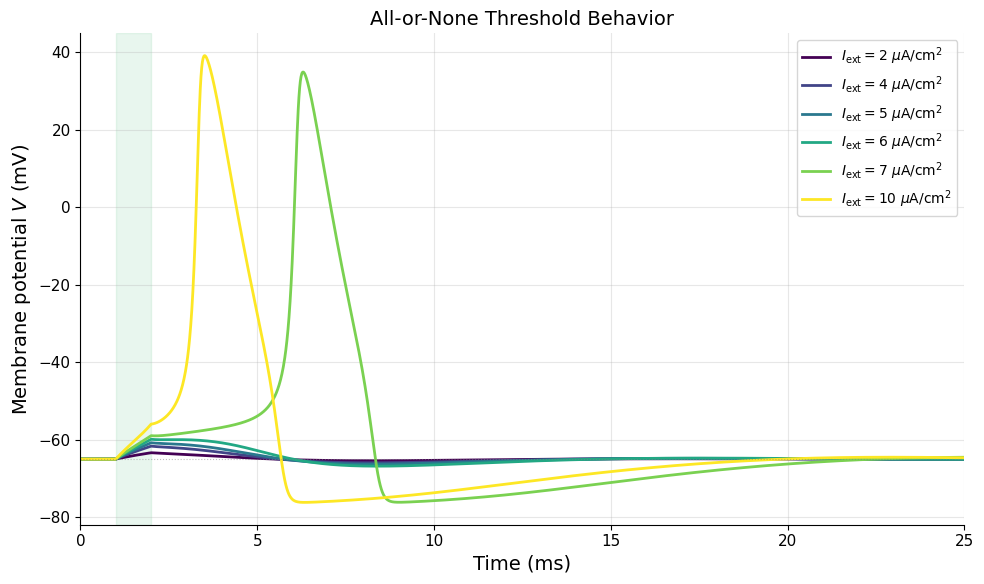

In [11]:
# Threshold behavior: responses to current pulses of varying amplitude

I_amplitudes = [2.0, 4.0, 5.0, 6.0, 7.0, 10.0]

fig, ax = plt.subplots(figsize=(10, 6))

# Use a colormap for the different amplitudes
cmap = plt.cm.viridis
n_amp = len(I_amplitudes)
colors_thresh = [cmap(i / (n_amp - 1)) for i in range(n_amp)]

dt_sim = 0.01
t_end_sim = 25.0
n_steps = int(t_end_sim / dt_sim)

for idx, I_amp in enumerate(I_amplitudes):
    I_ext = np.zeros(n_steps)
    I_ext[int(1.0 / dt_sim):int(2.0 / dt_sim)] = I_amp
    t_sim, y_sim = hh_solve_current_array(I_ext, dt_sim)

    ax.plot(t_sim, y_sim[:, 0], color=colors_thresh[idx], linewidth=2,
            label=r'$I_{\mathrm{ext}} = ' + f'{I_amp:.0f}$' + r' $\mu$A/cm$^2$')

ax.axvspan(1.0, 2.0, alpha=0.1, color=COLORS['green'])
ax.axhline(-65, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Membrane potential $V$ (mV)')
ax.set_title('All-or-None Threshold Behavior')
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(0, 25)

plt.tight_layout()
plt.show()

## 5.3 Refractory Periods

Immediately after an action potential, the neuron enters a **refractory period** during which it is either impossible or difficult to elicit a second spike. There are two phases:

- **Absolute refractory period** ($\sim 1\text{--}2 \; \text{ms}$): No stimulus, no matter how strong, can trigger another spike. This is because the Na$^+$ inactivation gate $h$ is near zero; the channels are physically blocked, and cannot be opened until $h$ recovers.

- **Relative refractory period** ($\sim 3\text{--}5 \; \text{ms}$): A second spike *can* be triggered, but only by a **stronger-than-normal** stimulus. During this period, $h$ is partially recovered but $n$ is still elevated (K$^+$ channels are still partly open), so the threshold is effectively raised.

We can demonstrate this with a **paired-pulse protocol**: deliver a first stimulus to trigger a spike, then deliver a second identical stimulus at varying delays.

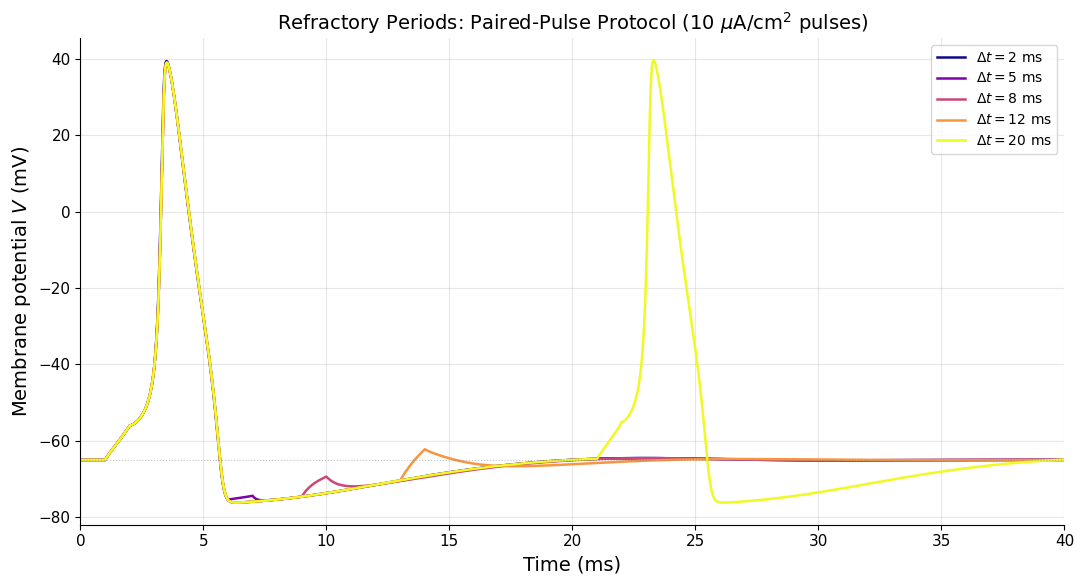

In [12]:
# Paired-pulse protocol to demonstrate refractory periods

delays = [2.0, 5.0, 8.0, 12.0, 20.0]  # ms between pulse onsets

fig, ax = plt.subplots(figsize=(11, 6))

cmap_ref = plt.cm.plasma
n_delays = len(delays)
colors_ref = [cmap_ref(i / (n_delays - 1)) for i in range(n_delays)]

dt_sim = 0.01
t_end_sim = 40.0
n_steps = int(t_end_sim / dt_sim)

for idx, delay in enumerate(delays):
    # Create paired pulse: first at t=1..2 ms, second at t=(1+delay)..(2+delay) ms
    I_ext = np.zeros(n_steps)
    I_ext[int(1.0 / dt_sim):int(2.0 / dt_sim)] = 10.0
    I_ext[int((1.0 + delay) / dt_sim):int((2.0 + delay) / dt_sim)] = 10.0
    t_sim, y_sim = hh_solve_current_array(I_ext, dt_sim)

    ax.plot(t_sim, y_sim[:, 0], color=colors_ref[idx], linewidth=1.8,
            label=f'$\Delta t = {delay:.0f}$ ms')

ax.axhline(-65, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Membrane potential $V$ (mV)')
ax.set_title(r'Refractory Periods: Paired-Pulse Protocol (10 $\mu$A/cm$^2$ pulses)')
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(0, 40)

plt.tight_layout()
plt.show()

## 5.4 Repetitive Firing and Frequency-Current Relationship

When a neuron receives sustained suprathreshold input, it fires **repetitive action potentials**: a spike train. The rate of firing encodes information about the stimulus intensity. Understanding the relationship between injected current and firing rate is central to neural coding theory.

The **frequency-current (f-I) curve** maps the firing rate (in Hz) as a function of the constant injected current $I_\text{ext}$. For the Hodgkin-Huxley model, this curve has a distinctive property: firing onset is **discontinuous**. Below threshold, the firing rate is zero; at threshold, it jumps to a finite frequency (typically $\sim 50\text{--}70 \; \text{Hz}$). This is the hallmark of **Type II excitability**, in contrast to Type I neurons (such as those modeled by the Connor-Stevens equations) where firing can begin at arbitrarily low frequencies.

The biophysical origin of Type II behavior in the HH model is the coexistence of the resting state with a **limit cycle** (periodic orbit) at the bifurcation point: specifically, a subcritical Hopf bifurcation. We will analyze this in detail in the dynamical systems sections; here, we demonstrate it computationally.

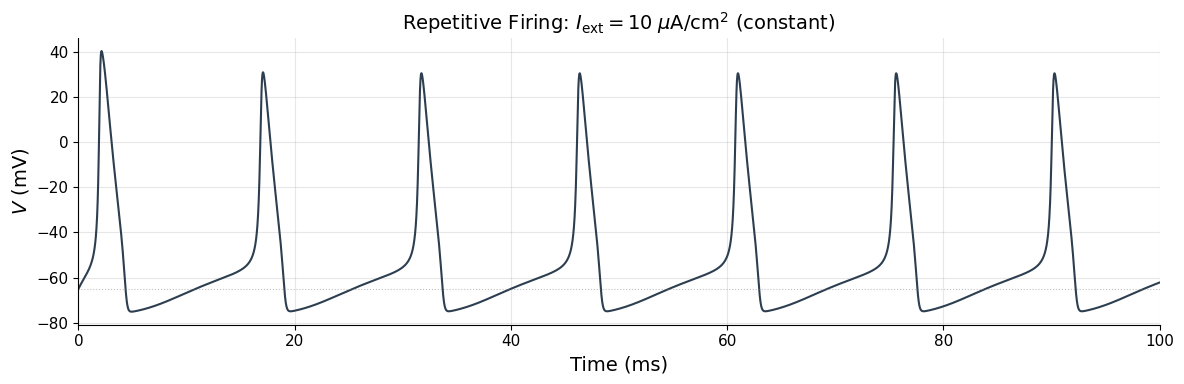

In [13]:
# Repetitive firing with constant suprathreshold current

t_rep, y_rep = hh_solve_constant(10.0, 100.0, 0.01)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_rep, y_rep[:, 0], color=COLORS['Vm'], linewidth=1.5)
ax.axhline(-65, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('$V$ (mV)')
ax.set_title(r'Repetitive Firing: $I_{\mathrm{ext}} = 10 \; \mu$A/cm$^2$ (constant)')
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

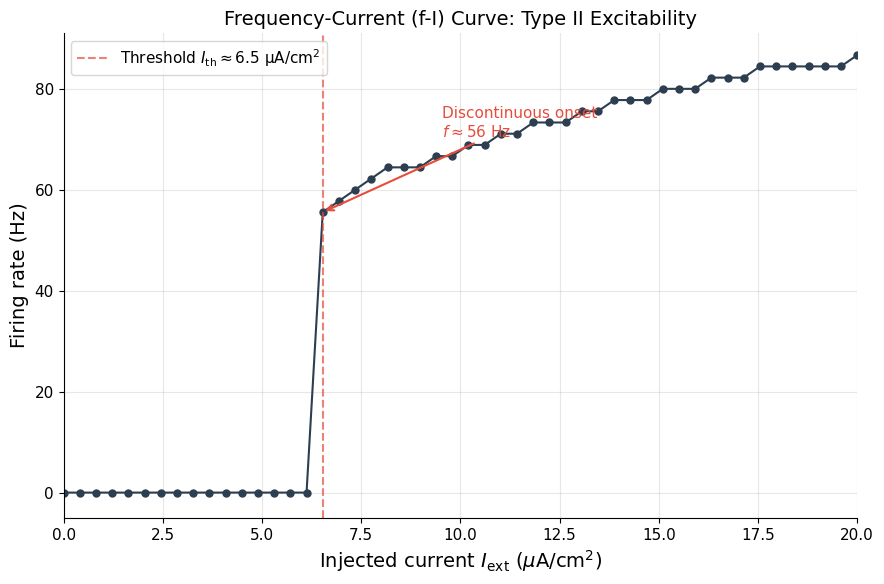

In [14]:
# Frequency-Current (f-I) curve
from neural_dynamics import compute_fi_curve_hh

# Compute f-I curve over a range of currents
currents, rates = compute_fi_curve_hh(
    I_range=(0.0, 20.0),
    n_points=50,
    t_sim=500.0,   # 500 ms simulation per current value
    dt=0.01,
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(currents, rates, 'o-', color=COLORS['Vm'], markersize=5, linewidth=1.5)

# Find threshold current (first nonzero firing rate)
firing_idx = np.where(rates > 0)[0]
if len(firing_idx) > 0:
    I_thresh = currents[firing_idx[0]]
    f_onset = rates[firing_idx[0]]
    ax.axvline(I_thresh, color=COLORS['Na'], linewidth=1.5, linestyle='--', alpha=0.7,
              label=f'Threshold $I_{{\\mathrm{{th}}}} \\approx {I_thresh:.1f}$ µA/cm$^2$')
    ax.annotate(f'Discontinuous onset\n$f \\approx {f_onset:.0f}$ Hz',
                xy=(I_thresh, f_onset), xytext=(I_thresh + 3, f_onset + 15),
                fontsize=11, color=COLORS['Na'],
                arrowprops=dict(arrowstyle='->', color=COLORS['Na'], lw=1.5))

ax.set_xlabel('Injected current $I_{\\mathrm{ext}}$ ($\\mu$A/cm$^2$)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title('Frequency-Current (f-I) Curve: Type II Excitability')
ax.legend(loc='upper left', fontsize=11)
ax.set_xlim(0, 20)
ax.set_ylim(bottom=-5)

plt.tight_layout()
plt.show()

## 5.5 Anode Break Excitation

One of the most counterintuitive predictions of the Hodgkin-Huxley model is **anode break excitation**: a neuron can fire an action potential *at the end* of a hyperpolarizing (inhibitory) stimulus, even though no depolarizing current is applied.

The mechanism is elegantly simple when understood through the gating variables:

1. **During hyperpolarization**: The membrane is held below rest. At these negative voltages, the Na$^+$ inactivation gate $h$ has a *higher* steady-state value than at rest (recall from Section 3 that $h_\infty$ increases at negative voltages). So $h$ gradually increases. Na$^+$ channels are being **de-inactivated**, priming them to open.

2. **Upon release**: When the hyperpolarizing current is removed, the membrane begins to return toward rest. But now $h$ is *larger than its resting value*: more Na$^+$ channels are available to open. As $V$ rises past threshold (even passively, driven by the leak current), the enhanced Na$^+$ availability triggers the positive feedback loop: $m$ gates open $\rightarrow$ Na$^+$ influx $\rightarrow$ depolarization $\rightarrow$ more $m$ gates open.

3. **Result**: A full action potential fires, triggered not by a depolarizing stimulus but by the *removal* of a hyperpolarizing one.

This phenomenon is also called **post-inhibitory rebound** and plays important roles in neural circuits, particularly in central pattern generators for rhythmic motor behaviors.

C:\Users\jorge.delarosa\AppData\Local\Temp\ipykernel_38508\879475454.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


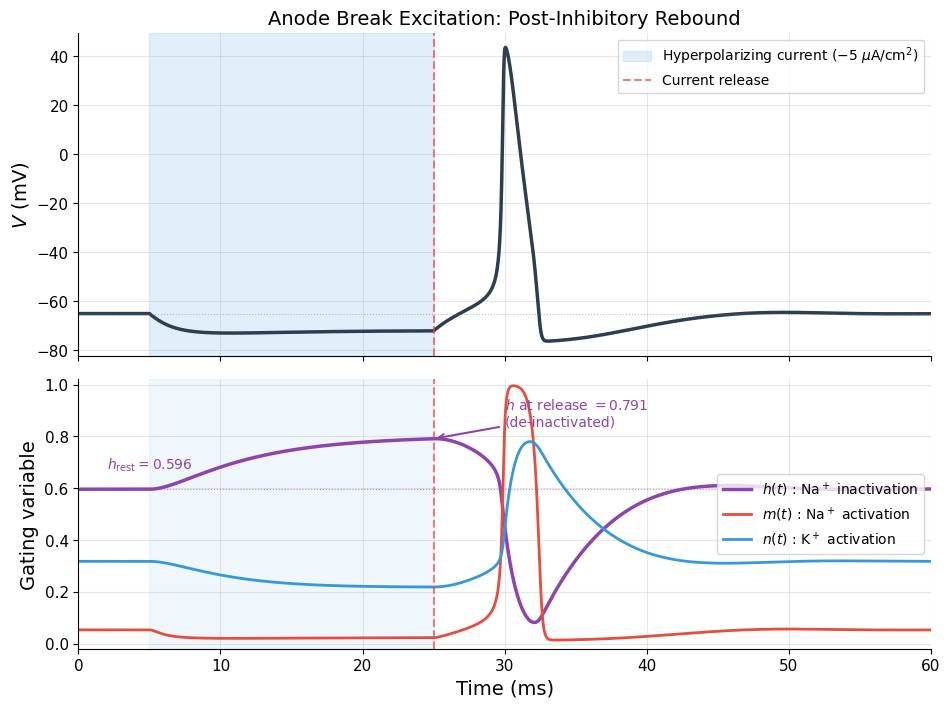

h at rest:              0.5961
h at release (t=25ms):  0.7912
h increase:             32.7%


In [15]:
# Anode break excitation: post-inhibitory rebound spike

dt_sim = 0.01
t_end_sim = 60.0
n_steps = int(t_end_sim / dt_sim)

# Hyperpolarizing current: -5 uA/cm2 for t in [5, 25] ms
I_ext = np.zeros(n_steps)
I_ext[int(5.0 / dt_sim):int(25.0 / dt_sim)] = -5.0

t_ab, y_ab = hh_solve_current_array(I_ext, dt_sim)

V_ab = y_ab[:, 0]
n_ab = y_ab[:, 1]
m_ab = y_ab[:, 2]
h_ab = y_ab[:, 3]

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                         gridspec_kw={'height_ratios': [1.2, 1], 'hspace': 0.08})

# Top panel: membrane potential
ax = axes[0]
ax.plot(t_ab, V_ab, color=COLORS['Vm'], linewidth=2.5)
ax.axhline(-65, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
ax.axvspan(5.0, 25.0, alpha=0.15, color=COLORS['K'],
           label=r'Hyperpolarizing current ($-5$ $\mu$A/cm$^2$)')
ax.axvline(25.0, color=COLORS['Na'], linewidth=1.5, linestyle='--', alpha=0.7,
           label='Current release')
ax.set_ylabel('$V$ (mV)')
ax.set_title('Anode Break Excitation: Post-Inhibitory Rebound')
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(0, 60)

# Bottom panel: gating variables (h is the key player)
ax2 = axes[1]
ax2.plot(t_ab, h_ab, color=COLORS['accent'], linewidth=2.5,
         label='$h(t)$ : Na$^+$ inactivation')
ax2.plot(t_ab, m_ab, color=COLORS['Na'], linewidth=2,
         label='$m(t)$ : Na$^+$ activation')
ax2.plot(t_ab, n_ab, color=COLORS['K'], linewidth=2,
         label='$n(t)$ : K$^+$ activation')

# Mark resting h value
h_rest = h_ab[0]
ax2.axhline(h_rest, color=COLORS['accent'], linewidth=0.8, linestyle=':', alpha=0.6)
ax2.annotate(f'$h_{{\\mathrm{{rest}}}} = {h_rest:.3f}$',
             xy=(0.5, h_rest), xytext=(2, h_rest + 0.08),
             fontsize=10, color=COLORS['accent'])

# Mark the elevated h at release
idx_release = int(25.0 / 0.01)
h_release = h_ab[idx_release]
ax2.annotate(f'$h$ at release $= {h_release:.3f}$\n(de-inactivated)',
             xy=(25.0, h_release), xytext=(30, h_release + 0.05),
             fontsize=10, color=COLORS['accent'],
             arrowprops=dict(arrowstyle='->', color=COLORS['accent'], lw=1.5))

ax2.axvspan(5.0, 25.0, alpha=0.08, color=COLORS['K'])
ax2.axvline(25.0, color=COLORS['Na'], linewidth=1.5, linestyle='--', alpha=0.7)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Gating variable')
ax2.legend(loc='right', fontsize=10)
ax2.set_ylim(-0.02, 1.02)
ax2.set_xlim(0, 60)

plt.tight_layout()
plt.show()

print(f"h at rest:              {h_rest:.4f}")
print(f"h at release (t=25ms):  {h_release:.4f}")
print(f"h increase:             {((h_release - h_rest)/h_rest)*100:.1f}%")

---

# 6. Phase Plane Analysis

Sections 4 and 5 explored the Hodgkin-Huxley model through *time-domain simulations*: we injected current, recorded voltage traces, and watched gating variables evolve. This approach reveals *what* the neuron does, but it does not fully explain *why* it does it. Why is there a sharp threshold? Why does repetitive firing start abruptly at a specific current? Why does the spike always have the same shape?

To answer these questions, we need a different perspective: not following a single trajectory through time, but mapping the **entire landscape of possible states** and understanding how the system flows through that landscape. This is the perspective of **dynamical systems theory**, and its primary visual tool is the **phase portrait**.

## 6.1 Motivation: Dimensionality Reduction

The HH model lives in a **four-dimensional state space** $(V, n, m, h)$. Visualizing trajectories in 4D is impossible for creatures confined to a 3D visual cortex. We need a principled way to reduce the dimensionality.

Fortunately, the HH system contains a natural **separation of timescales** that makes reduction possible:

1. **$m(t)$ is much faster than $n(t)$ and $h(t)$.** Recall from Section 3 that $\tau_m \approx 0.05\text{-}0.5 \; \text{ms}$, while $\tau_n \approx 1\text{-}8 \; \text{ms}$ and $\tau_h \approx 1\text{-}9 \; \text{ms}$. The fast variable $m$ reaches its steady-state $m_\infty(V)$ quasi-instantaneously relative to the slow dynamics of $V$, $n$, and $h$. We can therefore replace $m(t)$ with $m_\infty(V)$ everywhere; the **quasi-steady-state approximation**.

2. **$h$ and $n$ are approximately linearly related.** Hodgkin and Huxley themselves noted that, empirically, $h(t) + n(t) \approx 0.83$ throughout the action potential. This is not a coincidence: it reflects the fact that $h_\infty(V) + n_\infty(V)$ varies only weakly with $V$. We can therefore eliminate $h$ using the approximation $h \approx 0.83 - n$.

These two reductions collapse the 4D system to a **2D system in the $(V, n)$ plane**:

$$C_m \frac{dV}{dt} = -\bar{g}_\text{Na} \, m_\infty(V)^3 \, (0.83 - n) \, (V - E_\text{Na}) - \bar{g}_\text{K} \, n^4 \, (V - E_\text{K}) - g_L \, (V - E_L) + I_\text{ext}$$

$$\frac{dn}{dt} = \alpha_n(V)(1 - n) - \beta_n(V) \, n$$

In two dimensions, we can draw **phase portraits** (complete pictures of the system’s dynamics) and apply the full machinery of planar dynamical systems theory: nullclines, fixed points, stability analysis, and bifurcation diagrams.

## 6.2 FitzHugh-Nagumo as Conceptual Bridge

Before diving into the full HH reduction, it is instructive to consider a **simplified caricature** that captures the essential topology of excitability.

In 1961, Richard FitzHugh proposed a two-variable model inspired by the van der Pol oscillator, and in 1962, Jin-ichi Nagumo built an electronic circuit implementing the same equations:

$$\frac{dv}{dt} = v - \frac{v^3}{3} - w + I_\text{ext} \qquad \text{(fast excitatory variable)}$$

$$\frac{dw}{dt} = \varepsilon\,(v + a - bw) \qquad \text{(slow recovery variable)}$$

Here $v$ is analogous to the membrane potential, $w$ is analogous to a slow recovery variable (like $n$), and $\varepsilon \ll 1$ enforces the timescale separation. The cubic $v - v^3/3$ term produces the **N-shaped** nullcline that is the geometric hallmark of excitability.

The FitzHugh-Nagumo model demonstrates that **excitability is a topological property**, not a biological one. Any 2D system with a cubic-like fast nullcline and a monotone slow nullcline will exhibit threshold behavior, all-or-none spikes, and refractory periods. The HH model is simply a biophysically grounded realization of this universal geometry.

We will now construct the full $(V, n)$ phase portrait for the HH reduction, which has the same qualitative structure as FitzHugh-Nagumo but uses the actual biophysical rate functions.

## 6.3 Nullclines

A **nullcline** is the set of points in the phase plane where one of the state variables has zero rate of change. For our 2D reduction:

- **$V$-nullcline** ($dV/dt = 0$): The curve $n = f(V)$ where the membrane potential is instantaneously stationary. Using $m = m_\infty(V)$ and $h = h_\infty(V)$:

$$0 = -\bar{g}_\text{Na} \, m_\infty(V)^3 \, h_\infty(V) \, (V - E_\text{Na}) - \bar{g}_\text{K} \, n^4 \, (V - E_\text{K}) - g_L(V - E_L) + I_\text{ext}$$

  Solving for $n$:

$$n^4 = \frac{I_\text{ext} - \bar{g}_\text{Na} \, m_\infty^3 \, h_\infty \, (V - E_\text{Na}) - g_L(V - E_L)}{\bar{g}_\text{K}(V - E_\text{K})} \;\;\Rightarrow\;\; n = \left(\frac{\cdots}{\bar{g}_\text{K}(V-E_\text{K})}\right)^{1/4}$$

  This curve has a characteristic **cubic (N-shaped)** profile, the geometric origin of excitability.

- **$n$-nullcline** ($dn/dt = 0$): The curve where $n$ is stationary, which is simply $n = n_\infty(V)$. This is a **monotone sigmoid** that increases from 0 to 1.

**Fixed points** of the system are the **intersections** of the two nullclines, where both $dV/dt = 0$ and $dn/dt = 0$ simultaneously. The number and position of these intersections, and how they change with $I_\text{ext}$, determine the qualitative behavior of the system.

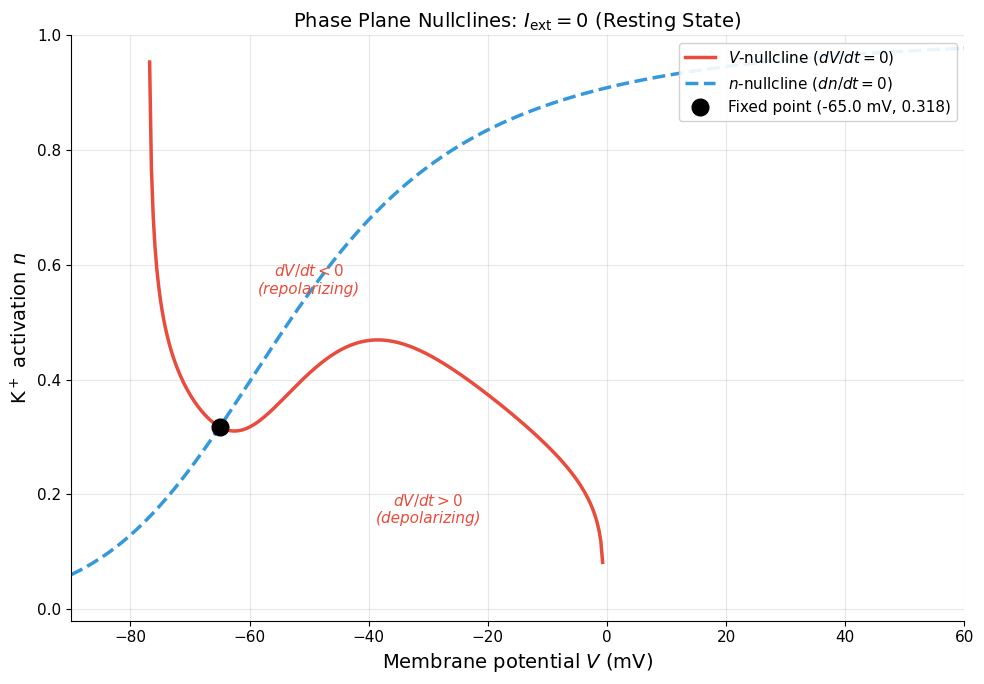

Fixed point: V = -65.00 mV, n = 0.3177


In [16]:
# Nullclines for I_ext = 0: the resting state geometry
from neural_dynamics import compute_nullclines, find_fixed_point, classify_fixed_point

V_range = (-90, 60)
V_arr, n_V_null, n_n_null = compute_nullclines(V_range, I_ext=0.0)

# Find fixed point
y_fp = find_fixed_point(I_ext=0.0)
V_fp, n_fp = y_fp[0], y_fp[1]

fig, ax = plt.subplots(figsize=(10, 7))

# V-nullcline (N-shaped)
mask_V = ~np.isnan(n_V_null)
ax.plot(V_arr[mask_V], n_V_null[mask_V], color=COLORS['Na'], linewidth=2.5,
        label=r'$V$-nullcline ($dV/dt = 0$)')

# n-nullcline (sigmoid)
ax.plot(V_arr, n_n_null, color=COLORS['K'], linewidth=2.5, linestyle='--',
        label=r'$n$-nullcline ($dn/dt = 0$)')

# Fixed point
ax.plot(V_fp, n_fp, 'ko', markersize=12, zorder=5,
        label=f'Fixed point ({V_fp:.1f} mV, {n_fp:.3f})')

# Flow direction annotations
ax.annotate(r'$dV/dt > 0$' + '\n(depolarizing)',
            xy=(-30, 0.15), fontsize=11, color=COLORS['Na'], fontstyle='italic',
            ha='center')
ax.annotate(r'$dV/dt < 0$' + '\n(repolarizing)',
            xy=(-50, 0.55), fontsize=11, color=COLORS['Na'], fontstyle='italic',
            ha='center')

ax.set_xlabel('Membrane potential $V$ (mV)')
ax.set_ylabel(r'K$^+$ activation $n$')
ax.set_title(r'Phase Plane Nullclines: $I_{\mathrm{ext}} = 0$ (Resting State)')
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.set_xlim(-90, 60)
ax.set_ylim(-0.02, 1.0)

plt.tight_layout()
plt.show()

print(f'Fixed point: V = {V_fp:.2f} mV, n = {n_fp:.4f}')

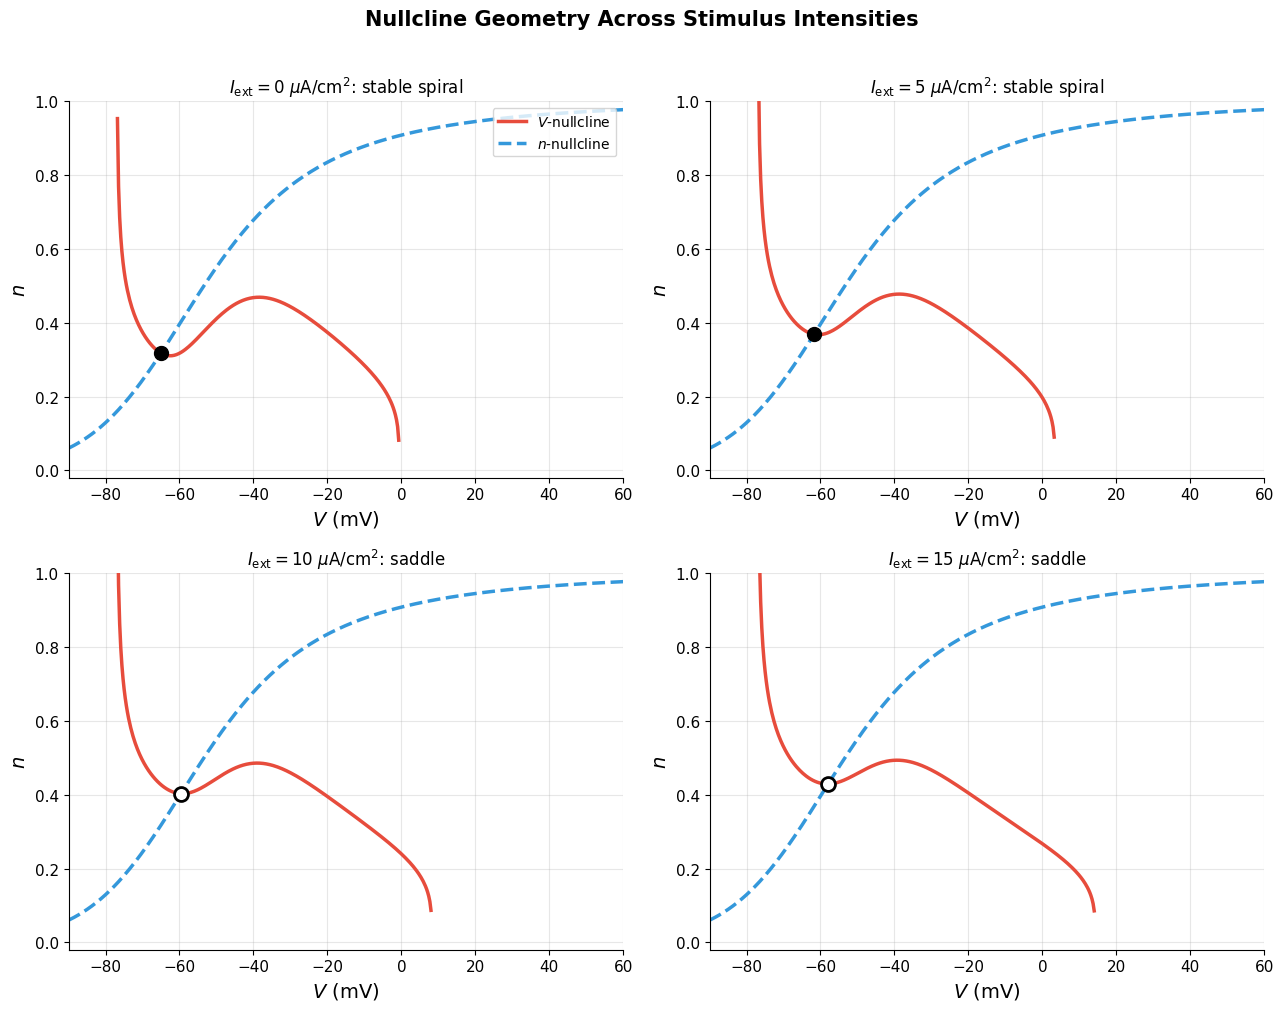

In [17]:
# How nullclines shift with I_ext: the geometry of excitability transition

I_values = [0.0, 5.0, 10.0, 15.0]
V_range = (-90, 60)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for idx, I_ext in enumerate(I_values):
    ax = axes[idx]
    V_arr, n_V_null, n_n_null = compute_nullclines(V_range, I_ext=I_ext)

    # V-nullcline
    mask = ~np.isnan(n_V_null)
    ax.plot(V_arr[mask], n_V_null[mask], color=COLORS['Na'], linewidth=2.5,
            label=r'$V$-nullcline')

    # n-nullcline (doesn't change with I_ext)
    ax.plot(V_arr, n_n_null, color=COLORS['K'], linewidth=2.5, linestyle='--',
            label=r'$n$-nullcline')

    # Find and classify fixed point
    try:
        y_fp = find_fixed_point(I_ext=I_ext)
        classification, eigenvalues = classify_fixed_point(y_fp, I_ext)
        V_fp, n_fp = y_fp[0], y_fp[1]

        # Filled circle for stable, open circle for unstable
        if 'stable' in classification:
            ax.plot(V_fp, n_fp, 'ko', markersize=10, zorder=5)
        else:
            ax.plot(V_fp, n_fp, 'o', color='white', markersize=10,
                    markeredgecolor='black', markeredgewidth=2, zorder=5)

        ax.set_title(
            f'$I_{{\\mathrm{{ext}}}} = {I_ext:.0f}$'
            f' $\\mu$A/cm$^2$: {classification}',
            fontsize=12,
        )
    except RuntimeError:
        ax.set_title(
            f'$I_{{\\mathrm{{ext}}}} = {I_ext:.0f}$ $\\mu$A/cm$^2$',
            fontsize=12,
        )

    ax.set_xlim(-90, 60)
    ax.set_ylim(-0.02, 1.0)
    ax.set_xlabel('$V$ (mV)')
    ax.set_ylabel('$n$')
    if idx == 0:
        ax.legend(loc='upper right', fontsize=10)

fig.suptitle('Nullcline Geometry Across Stimulus Intensities', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6.4 Linear Stability Analysis

Finding a fixed point tells us *where* the system can be stationary, but not *how* it behaves near that point. Does the system return to the fixed point after a small perturbation (stable), or does it diverge (unstable)? Does it spiral or approach monotonically?

To answer these questions, we **linearize** the system around the fixed point. Let $\mathbf{y}^*$ be a fixed point where $\mathbf{f}(\mathbf{y}^*) = 0$, and consider a small perturbation $\delta\mathbf{y} = \mathbf{y} - \mathbf{y}^*$. Taylor-expanding to first order:

$$\frac{d(\delta\mathbf{y})}{dt} = \mathbf{f}(\mathbf{y}^* + \delta\mathbf{y}) \approx \underbrace{\mathbf{f}(\mathbf{y}^*)}_{= \, 0} + \mathbf{J} \, \delta\mathbf{y}$$

where $\mathbf{J}$ is the **Jacobian matrix** evaluated at the fixed point:

$$J_{ij} = \frac{\partial f_i}{\partial y_j}\bigg|_{\mathbf{y} = \mathbf{y}^*}$$

The linearized system $\delta\mathbf{y}\,' = \mathbf{J}\,\delta\mathbf{y}$ has the general solution $\delta\mathbf{y}(t) = \sum_k c_k \, \mathbf{v}_k \, e^{\lambda_k t}$, where $\lambda_k$ and $\mathbf{v}_k$ are the eigenvalues and eigenvectors of $\mathbf{J}$. The **eigenvalues** therefore determine everything about the local dynamics:

| Eigenvalue type | Condition | Behavior | Classification |
|:---|:---|:---|:---|
| All real, all $\text{Re}(\lambda) < 0$ | $\lambda_k \in \mathbb{R}$, $\lambda_k < 0$ | Monotone decay | **Stable node** |
| All real, any $\text{Re}(\lambda) > 0$ | $\lambda_k \in \mathbb{R}$, $\exists \, \lambda_k > 0$ | Monotone growth | **Unstable node** |
| Real, mixed signs | $\lambda_1 < 0 < \lambda_2$ | Saddle dynamics | **Saddle point** |
| Complex, $\text{Re}(\lambda) < 0$ | $\lambda = \sigma \pm i\omega$, $\sigma < 0$ | Damped oscillations | **Stable spiral** |
| Complex, $\text{Re}(\lambda) > 0$ | $\lambda = \sigma \pm i\omega$, $\sigma > 0$ | Growing oscillations | **Unstable spiral** |
| Complex, $\text{Re}(\lambda) = 0$ | $\lambda = \pm i\omega$ | Sustained oscillations | **Center** (marginal) |

In [18]:
# Jacobian and eigenvalue analysis at the resting state (I_ext = 0)
from neural_dynamics import compute_jacobian_hh, classify_fixed_point

y_fp = find_fixed_point(I_ext=0.0)
J = compute_jacobian_hh(y_fp, I_ext=0.0)
classification, eigenvalues = classify_fixed_point(y_fp, I_ext=0.0)

print('=' * 65)
print('LINEAR STABILITY ANALYSIS AT REST (I_ext = 0)')
print('=' * 65)
print()
print(f'Fixed point: V = {y_fp[0]:.3f} mV')
print(f'             n = {y_fp[1]:.5f}')
print(f'             m = {y_fp[2]:.5f}')
print(f'             h = {y_fp[3]:.5f}')
print()
print('Jacobian matrix J (4x4):')
print('-' * 65)
labels = ['V', 'n', 'm', 'h']
header = '         ' + '  '.join(f'{s:>10s}' for s in ['dV', 'dn', 'dm', 'dh'])
print(header)
for i in range(4):
    row = '  '.join(f'{J[i, j]:10.4f}' for j in range(4))
    print(f'  d{labels[i]}/dt |  {row}')
print()
print('Eigenvalues:')
print('-' * 65)
for k, lam in enumerate(eigenvalues):
    re, im = np.real(lam), np.imag(lam)
    if abs(im) < 1e-8:
        print(f'  \u03bb_{k+1} = {re:.4f} (real)')
    else:
        print(f'  \u03bb_{k+1} = {re:.4f} \u00b1 {abs(im):.4f}i (complex)')
print()
print(f'Classification: {classification}')
print()
print('Physical interpretation:')
print('  All eigenvalue real parts are negative => perturbations decay.')
print('  Complex eigenvalues => the decay is oscillatory (damped ringing).')
print('  This is why subthreshold stimuli produce damped oscillations.')

LINEAR STABILITY ANALYSIS AT REST (I_ext = 0)

Fixed point: V = -65.000 mV
             n = 0.31768
             m = 0.05293
             h = 0.59611

Jacobian matrix J (4x4):
-----------------------------------------------------------------
                 dV          dn          dm          dh
  dV/dt |     -0.6773    -55.4024     69.1512      2.0469
  dn/dt |      0.0028     -0.1832      0.0000      0.0000
  dm/dt |      0.0264      0.0000     -4.2235      0.0000
  dh/dt |     -0.0041      0.0000      0.0000     -0.1174

Eigenvalues:
-----------------------------------------------------------------
  λ_1 = -4.6753 (real)
  λ_2 = -0.2027 ± 0.3831i (complex)
  λ_3 = -0.2027 ± 0.3831i (complex)
  λ_4 = -0.1207 (real)

Classification: stable spiral

Physical interpretation:
  All eigenvalue real parts are negative => perturbations decay.
  Complex eigenvalues => the decay is oscillatory (damped ringing).
  This is why subthreshold stimuli produce damped oscillations.


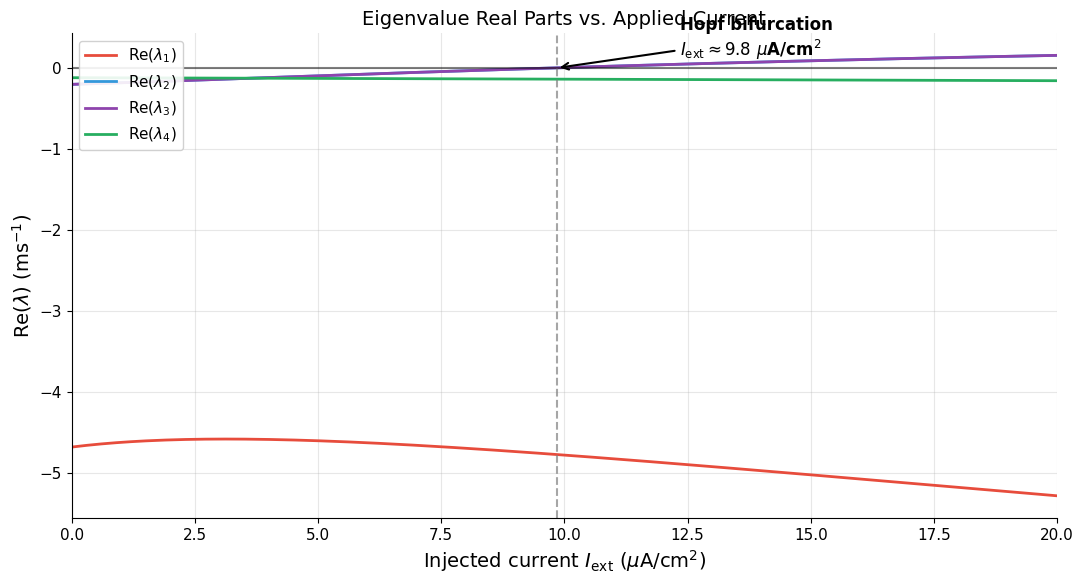

Stability classification along the current sweep:
  I_ext =   0.00 µA/cm² : stable spiral
  I_ext =   9.85 µA/cm² : saddle


In [19]:
# Track eigenvalue real parts as I_ext increases: finding the bifurcation
from neural_dynamics import bifurcation_sweep

currents_bif, V_fps_bif, real_eigs, classifications_bif = bifurcation_sweep(
    I_range=(0.0, 20.0), n_points=200
)

fig, ax = plt.subplots(figsize=(11, 6))

eig_colors = [COLORS['Na'], COLORS['K'], COLORS['accent'], COLORS['green']]
eig_labels = [r'$\mathrm{Re}(\lambda_1)$', r'$\mathrm{Re}(\lambda_2)$',
              r'$\mathrm{Re}(\lambda_3)$', r'$\mathrm{Re}(\lambda_4)$']

for k in range(4):
    ax.plot(currents_bif, real_eigs[:, k], color=eig_colors[k],
            linewidth=2, label=eig_labels[k])

# Zero line (stability boundary)
ax.axhline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.5)

# Find approximate bifurcation point (where max real part crosses zero)
max_real = np.max(real_eigs, axis=1)
for i in range(1, len(max_real)):
    if max_real[i-1] < 0 and max_real[i] >= 0:
        I_bif = currents_bif[i]
        ax.axvline(I_bif, color='gray', linewidth=1.5, linestyle='--', alpha=0.7)
        ax.annotate(
            f'Hopf bifurcation\n'
            f'$I_{{\\mathrm{{ext}}}} \\approx {I_bif:.1f}$ $\\mu$A/cm$^2$',
            xy=(I_bif, 0), xytext=(I_bif + 2.5, 0.15),
            fontsize=12, color='black', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
        )
        break

ax.set_xlabel(r'Injected current $I_{\mathrm{ext}}$ ($\mu$A/cm$^2$)')
ax.set_ylabel(r'$\mathrm{Re}(\lambda)$ (ms$^{-1}$)')
ax.set_title('Eigenvalue Real Parts vs. Applied Current')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.set_xlim(0, 20)

plt.tight_layout()
plt.show()

# Print the transition
print('Stability classification along the current sweep:')
unique_transitions = []
prev = classifications_bif[0]
unique_transitions.append((currents_bif[0], prev))
for i in range(1, len(classifications_bif)):
    if classifications_bif[i] != prev:
        unique_transitions.append((currents_bif[i], classifications_bif[i]))
        prev = classifications_bif[i]
for I_val, cls in unique_transitions:
    print(f'  I_ext = {I_val:6.2f} \u00b5A/cm\u00b2 : {cls}')

## 6.5 Vector Field and Trajectories

Nullclines partition the phase plane into regions where $dV/dt$ and $dn/dt$ have definite signs. The **vector field** $\big(dV/dt, \, dn/dt\big)$ at each point $(V, n)$ shows the direction and magnitude of the system’s flow. Overlaying trajectories on this vector field reveals the geometry of spikes, threshold, and limit cycles in their full glory.

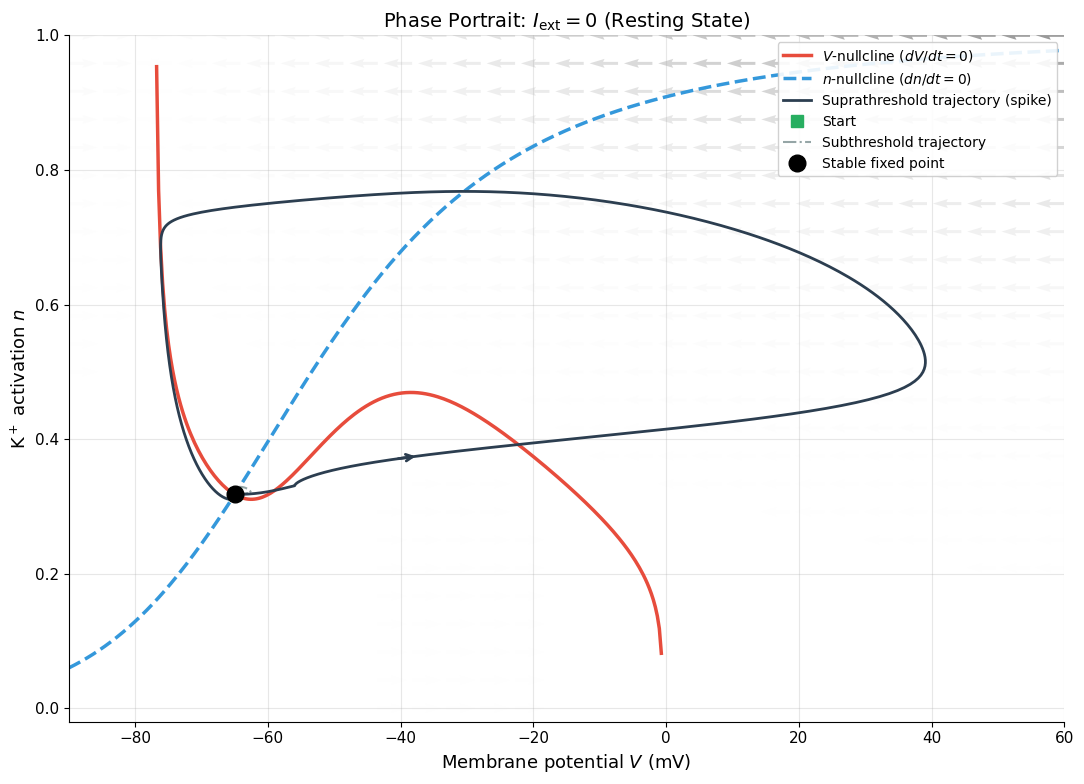

In [20]:
# Phase portrait in the (V, n) plane: I_ext = 0 (resting state + perturbation)

# Define the 2D reduced HH right-hand side
params = HH_DEFAULT_PARAMS
C_m_val, g_Na_val, g_K_val, g_L_val, E_Na_val, E_K_val, E_L_val = params

def hh_2d_rhs(V, n, I_ext):
    "2D reduced HH: m = m_inf(V), h = h_inf(V)."
    m = m_inf(V)
    h = h_inf(V)
    I_Na = g_Na_val * m**3 * h * (V - E_Na_val)
    I_K  = g_K_val * n**4 * (V - E_K_val)
    I_L  = g_L_val * (V - E_L_val)
    dVdt = (I_ext - I_Na - I_K - I_L) / C_m_val
    dndt = alpha_n(V) * (1.0 - n) - beta_n(V) * n
    return dVdt, dndt

# Create vector field grid
V_grid = np.linspace(-90, 60, 30)
n_grid = np.linspace(0.0, 1.0, 25)
VV, NN = np.meshgrid(V_grid, n_grid)
dV = np.zeros_like(VV)
dN = np.zeros_like(NN)

for i in range(VV.shape[0]):
    for j in range(VV.shape[1]):
        dv, dn_val = hh_2d_rhs(VV[i, j], NN[i, j], 0.0)
        dV[i, j] = dv
        dN[i, j] = dn_val

# Normalize arrows for visibility
speed = np.sqrt(dV**2 + dN**2)
speed[speed == 0] = 1.0
dV_norm = dV / speed
dN_norm = dN / speed

# Simulate a suprathreshold trajectory: brief pulse at t=0.5..1.5 ms
dt_sim = 0.01
t_end_traj = 20.0
n_steps_traj = int(t_end_traj / dt_sim)
I_brief = np.zeros(n_steps_traj)
I_brief[int(0.5 / dt_sim):int(1.5 / dt_sim)] = 10.0
t_traj, y_traj = hh_solve_current_array(I_brief, dt_sim)

# Also simulate a subthreshold trajectory
I_weak = np.zeros(n_steps_traj)
I_weak[int(0.5 / dt_sim):int(1.5 / dt_sim)] = 3.0
t_sub, y_sub = hh_solve_current_array(I_weak, dt_sim)

# Get nullclines
V_nc, n_V_nc, n_n_nc = compute_nullclines((-90, 60), I_ext=0.0, n_points=500)

# Fixed point
y_fp0 = find_fixed_point(I_ext=0.0)

# Plot
fig, ax = plt.subplots(figsize=(11, 8))

# Vector field
ax.quiver(VV, NN, dV_norm, dN_norm, speed, cmap='Greys', alpha=0.4,
          scale=35, width=0.003)

# Nullclines
mask_nc = ~np.isnan(n_V_nc)
ax.plot(V_nc[mask_nc], n_V_nc[mask_nc], color=COLORS['Na'], linewidth=2.5,
        label=r'$V$-nullcline ($dV/dt = 0$)')
ax.plot(V_nc, n_n_nc, color=COLORS['K'], linewidth=2.5, linestyle='--',
        label=r'$n$-nullcline ($dn/dt = 0$)')

# Suprathreshold trajectory (the spike!)
ax.plot(y_traj[:, 0], y_traj[:, 1], color=COLORS['Vm'], linewidth=2,
        label='Suprathreshold trajectory (spike)', zorder=4)
ax.plot(y_traj[0, 0], y_traj[0, 1], 's', color=COLORS['green'], markersize=8,
        zorder=5, label='Start')
# Arrow to show direction along spike trajectory
mid_idx = len(y_traj) // 8
ax.annotate('', xy=(y_traj[mid_idx+5, 0], y_traj[mid_idx+5, 1]),
            xytext=(y_traj[mid_idx, 0], y_traj[mid_idx, 1]),
            arrowprops=dict(arrowstyle='->', color=COLORS['Vm'], lw=2))

# Subthreshold trajectory
ax.plot(y_sub[:, 0], y_sub[:, 1], color=COLORS['leak'], linewidth=1.5,
        linestyle='-.', label='Subthreshold trajectory', zorder=3)

# Fixed point
ax.plot(y_fp0[0], y_fp0[1], 'ko', markersize=12, zorder=6,
        label='Stable fixed point')

ax.set_xlabel('Membrane potential $V$ (mV)', fontsize=13)
ax.set_ylabel(r'K$^+$ activation $n$', fontsize=13)
ax.set_title(r'Phase Portrait: $I_{\mathrm{ext}} = 0$ (Resting State)', fontsize=14)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.set_xlim(-90, 60)
ax.set_ylim(-0.02, 1.0)

plt.tight_layout()
plt.show()

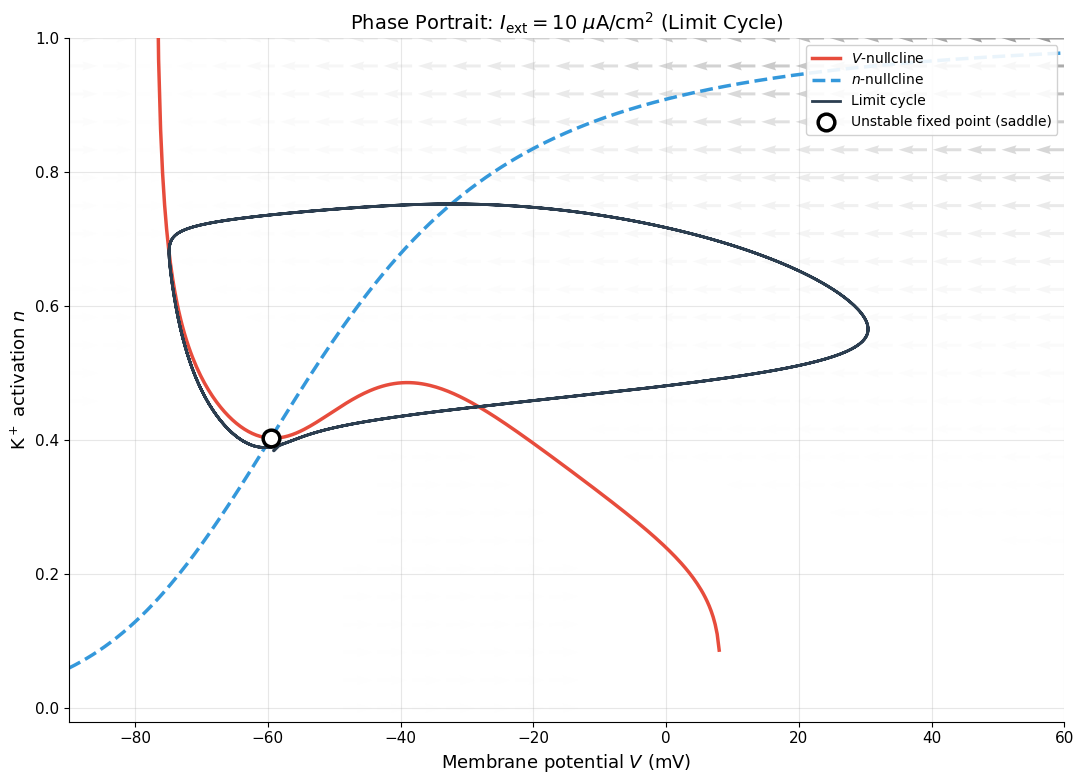

Fixed point at I_ext = 10: V = -59.57 mV, classification = saddle
Eigenvalues: [-4.77410700e+00+0.j          4.12851804e-03+0.58833125j
  4.12851804e-03-0.58833125j -1.38902761e-01+0.j        ]


In [21]:
# Phase portrait in the (V, n) plane: I_ext = 10 (oscillating regime)

# Vector field for I_ext = 10
dV_10 = np.zeros_like(VV)
dN_10 = np.zeros_like(NN)
for i in range(VV.shape[0]):
    for j in range(VV.shape[1]):
        dv, dn_val = hh_2d_rhs(VV[i, j], NN[i, j], 10.0)
        dV_10[i, j] = dv
        dN_10[i, j] = dn_val

speed_10 = np.sqrt(dV_10**2 + dN_10**2)
speed_10[speed_10 == 0] = 1.0
dV_10n = dV_10 / speed_10
dN_10n = dN_10 / speed_10

# Simulate limit cycle trajectory with constant I_ext = 10
t_lc, y_lc = hh_solve_constant(10.0, 100.0, 0.01)

# Use the last few cycles (skip transient)
skip_lc = int(50.0 / 0.01) # skip first 50 ms
V_lc = y_lc[skip_lc:, 0]
n_lc = y_lc[skip_lc:, 1]

# Nullclines for I_ext = 10
V_nc10, n_V_nc10, n_n_nc10 = compute_nullclines((-90, 60), I_ext=10.0,
                                                  n_points=500)

# Fixed point for I_ext = 10
y_fp10 = find_fixed_point(I_ext=10.0)
cls_10, eigs_10 = classify_fixed_point(y_fp10, I_ext=10.0)

fig, ax = plt.subplots(figsize=(11, 8))

# Vector field
ax.quiver(VV, NN, dV_10n, dN_10n, speed_10, cmap='Greys', alpha=0.4,
          scale=35, width=0.003)

# Nullclines
mask_10 = ~np.isnan(n_V_nc10)
ax.plot(V_nc10[mask_10], n_V_nc10[mask_10], color=COLORS['Na'], linewidth=2.5,
        label=r'$V$-nullcline')
ax.plot(V_nc10, n_n_nc10, color=COLORS['K'], linewidth=2.5, linestyle='--',
        label=r'$n$-nullcline')

# Limit cycle trajectory
ax.plot(V_lc, n_lc, color=COLORS['Vm'], linewidth=2,
        label='Limit cycle', zorder=4)

# Direction arrow on limit cycle
arrow_idx = len(V_lc) // 6
ax.annotate('', xy=(V_lc[arrow_idx+10], n_lc[arrow_idx+10]),
            xytext=(V_lc[arrow_idx], n_lc[arrow_idx]),
            arrowprops=dict(arrowstyle='->', color=COLORS['Vm'], lw=2.5))

# Unstable fixed point (open circle)
ax.plot(y_fp10[0], y_fp10[1], 'o', color='white', markersize=12,
        markeredgecolor='black', markeredgewidth=2.5, zorder=6,
        label=f'Unstable fixed point ({cls_10})')

ax.set_xlabel('Membrane potential $V$ (mV)', fontsize=13)
ax.set_ylabel(r'K$^+$ activation $n$', fontsize=13)
ax.set_title(
    r'Phase Portrait: $I_{\mathrm{ext}} = 10$ $\mu$A/cm$^2$ (Limit Cycle)',
    fontsize=14,
)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.set_xlim(-90, 60)
ax.set_ylim(-0.02, 1.0)

plt.tight_layout()
plt.show()

print(f'Fixed point at I_ext = 10: V = {y_fp10[0]:.2f} mV, '
      f'classification = {cls_10}')
print(f'Eigenvalues: {eigs_10}')

---

# 7. Dynamical Stability and Bifurcations

In Section 6, we saw that the fixed point of the HH system changes its stability as $I_\text{ext}$ increases: at rest ($I_\text{ext} = 0$), the fixed point is a **stable spiral**; at higher currents, eigenvalues cross the imaginary axis and the fixed point becomes an **unstable spiral**, with a limit cycle (periodic firing) appearing in its place.

This qualitative change in the system’s behavior at a critical parameter value is called a **bifurcation**. Bifurcation theory is the mathematical framework for classifying and predicting such transitions. In this section, we analyze the specific type of bifurcation in the HH model, its consequences for neural coding, and the remarkable phenomenon of hysteresis that it produces.

## 7.1 What is a Bifurcation?

A **bifurcation** occurs when a smooth, small change in a parameter causes a **topological change** in the system’s phase portrait: the number of fixed points changes, a fixed point changes stability, or a periodic orbit appears or disappears.

The key idea is that we are not just studying one dynamical system, but a **family** of dynamical systems parameterized by some control parameter (here, $I_\text{ext}$). As we tune this parameter, the vector field deforms continuously, but the *qualitative structure* of the flow can change discontinuously at isolated critical values. These critical values are the **bifurcation points**.

In the Hodgkin-Huxley model, $I_\text{ext}$ is the bifurcation parameter, and we have already seen evidence of a bifurcation: the transition from a stable resting state (no firing) to periodic spiking (repetitive firing) as current increases. The precise nature of this bifurcation has profound consequences for how the neuron encodes information.

## 7.2 Hopf Bifurcation in the HH Model

As $I_\text{ext}$ increases from zero, the fixed point of the HH system undergoes the following sequence of changes:

1. **Low current** ($I_\text{ext} \lesssim 6$ $\mu$A/cm$^2$): The fixed point is a **stable spiral**. The eigenvalues are complex with negative real parts: $\lambda = \sigma \pm i\omega$ with $\sigma < 0$. Perturbations produce **damped oscillations** that decay back to rest. The neuron does not fire.

2. **Critical current** ($I_\text{ext} \approx 6\text{-}10$ $\mu$A/cm$^2$): The real part of the complex eigenvalues crosses zero: $\sigma = 0$. At this instant, the fixed point is a **center**: perturbations neither grow nor decay.

3. **Above critical current**: $\sigma > 0$, and the fixed point becomes an **unstable spiral**. Perturbations grow, and the trajectory is captured by a **stable limit cycle**: the periodic spike train.

This scenario (a fixed point losing stability through complex eigenvalues crossing the imaginary axis, accompanied by the birth of a limit cycle) is called a **Hopf bifurcation**.

### Supercritical vs. Subcritical Hopf

There are two flavors of Hopf bifurcation, with dramatically different physical consequences:

- **Supercritical Hopf**: The limit cycle is born *at* the bifurcation with **zero amplitude** and grows smoothly as the parameter moves past the critical value. Oscillations appear gradually.

- **Subcritical Hopf**: An *unstable* limit cycle exists below the bifurcation point, shrinks as the parameter approaches the critical value, and collides with the fixed point at the bifurcation. Beyond the critical point, the system jumps to a **large-amplitude** limit cycle that already existed further from the fixed point. The onset of oscillations is **sudden and discontinuous**.

The HH model exhibits a **subcritical Hopf bifurcation**. This has two critical consequences:

1. **Discontinuous onset of firing**: The neuron jumps from silence to finite-frequency spiking, with no intermediate regime of infinitesimally small oscillations.

2. **Hysteresis**: Because the large-amplitude limit cycle exists even below the bifurcation point (in a range where both the stable fixed point and the limit cycle coexist), the system exhibits **bistability**. Once firing is established, it can persist even when the current is reduced below the onset threshold.

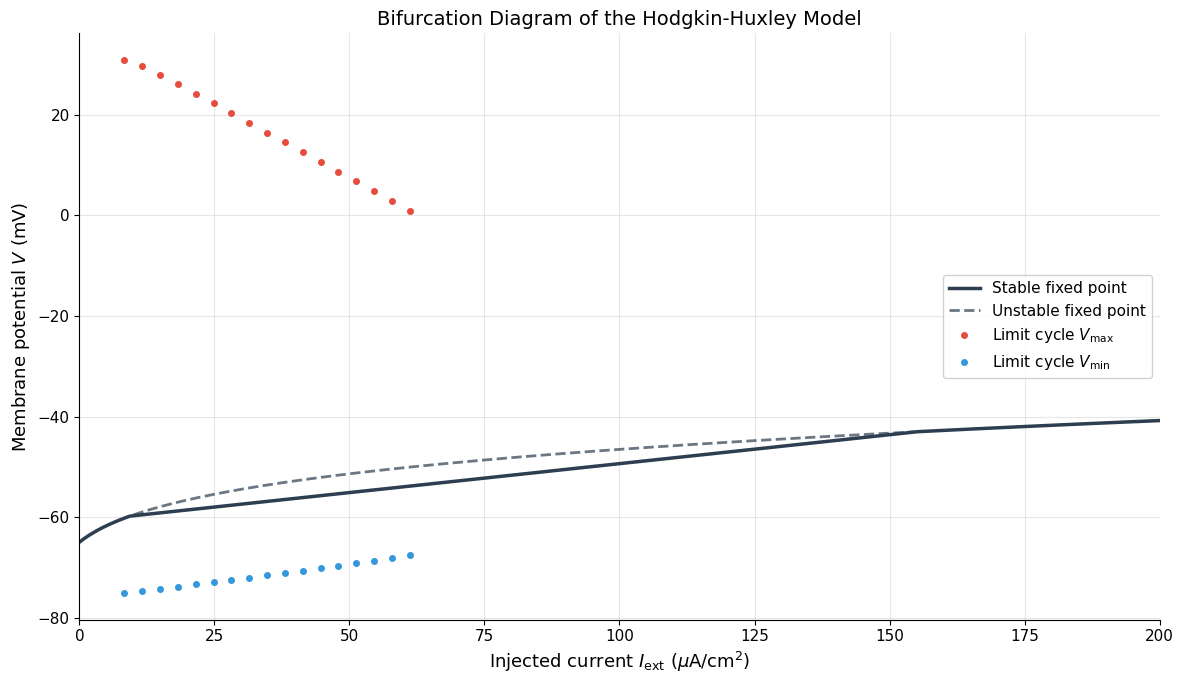

In [22]:
# Bifurcation diagram: fixed point branch + limit cycle extrema

# Fixed point branch
I_sweep = np.linspace(0.0, 200.0, 300)
V_fp_branch = np.zeros(len(I_sweep))
cls_branch = []
V_guess = -65.0

for i, I_val in enumerate(I_sweep):
    try:
        y_fp = find_fixed_point(I_val, V0_guess=V_guess)
        classification, _ = classify_fixed_point(y_fp, I_val)
        V_fp_branch[i] = y_fp[0]
        cls_branch.append(classification)
        V_guess = y_fp[0]
    except RuntimeError:
        V_fp_branch[i] = np.nan
        cls_branch.append('no convergence')

# Classify stable vs unstable segments
stable_mask = np.array(['stable' in c for c in cls_branch])
unstable_mask = ~stable_mask

# Limit cycle extrema from simulations using hh_solve_constant
I_lc_range = np.linspace(5.0, 200.0, 60)
V_max_lc = np.full(len(I_lc_range), np.nan)
V_min_lc = np.full(len(I_lc_range), np.nan)

from neural_dynamics.analysis import _count_spikes

for i, I_val in enumerate(I_lc_range):
    t_sim, y_sim = hh_solve_constant(I_val, 300.0, 0.01)

    # Skip transient (first 100 ms)
    skip = int(100.0 / 0.01)
    V_trace = y_sim[skip:, 0]

    # Check if there are spikes
    n_spikes = _count_spikes(V_trace)
    if n_spikes >= 2:
        V_max_lc[i] = np.max(V_trace)
        V_min_lc[i] = np.min(V_trace)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Stable fixed point branch (solid)
I_stable = I_sweep[stable_mask]
V_stable = V_fp_branch[stable_mask]
if len(I_stable) > 0:
    ax.plot(I_stable, V_stable, color=COLORS['Vm'], linewidth=2.5,
            label='Stable fixed point')

# Unstable fixed point branch (dashed)
I_unstable = I_sweep[unstable_mask]
V_unstable = V_fp_branch[unstable_mask]
if len(I_unstable) > 0:
    ax.plot(I_unstable, V_unstable, color=COLORS['Vm'], linewidth=2,
            linestyle='--', alpha=0.7, label='Unstable fixed point')

# Limit cycle max/min
lc_mask = ~np.isnan(V_max_lc)
ax.plot(I_lc_range[lc_mask], V_max_lc[lc_mask], 'o', color=COLORS['Na'],
        markersize=4, label=r'Limit cycle $V_{\mathrm{max}}$')
ax.plot(I_lc_range[lc_mask], V_min_lc[lc_mask], 'o', color=COLORS['K'],
        markersize=4, label=r'Limit cycle $V_{\mathrm{min}}$')

ax.set_xlabel(r'Injected current $I_{\mathrm{ext}}$ ($\mu$A/cm$^2$)', fontsize=13)
ax.set_ylabel('Membrane potential $V$ (mV)', fontsize=13)
ax.set_title('Bifurcation Diagram of the Hodgkin-Huxley Model', fontsize=14)
ax.legend(loc='right', fontsize=11, framealpha=0.9)
ax.set_xlim(0, 200)

plt.tight_layout()
plt.show()

## 7.3 Type I vs. Type II Excitability

The type of bifurcation at firing onset has a profound consequence for how the neuron encodes stimulus intensity into firing rate. Neurons are classified into two fundamental types based on their **frequency-current (f-I) relationship**:

### Type I Excitability (SNIC Bifurcation)

In a **Saddle-Node on an Invariant Circle (SNIC)** bifurcation, a stable fixed point and a saddle point collide and annihilate on a periodic orbit. After the bifurcation, the trajectory must traverse the “ghost” of the vanished fixed points, which slows it down. The result:

- Firing rate starts from **arbitrarily close to zero** at threshold
- $f(I) \propto \sqrt{I - I_\text{th}}$ near threshold (a square-root law)
- The neuron can fire at **any frequency** above zero
- Continuous onset of firing

### Type II Excitability (Hopf Bifurcation)

In a **Hopf bifurcation** (especially subcritical), a stable fixed point loses stability to an oscillation with a characteristic frequency $\omega$. The result:

- Firing starts at a **nonzero minimum frequency** $f_\text{min} > 0$
- **Discontinuous jump** from silence to $f_\text{min}$ at threshold
- The neuron **cannot** fire below $f_\text{min}$
- The HH model is **Type II**, as we demonstrated in Section 5.4

This classification has deep implications for neural coding. Type I neurons are better suited for **rate coding** (smoothly encoding stimulus intensity). Type II neurons are better at **coincidence detection** (responding to synchronous inputs, since they prefer inputs at their resonant frequency).

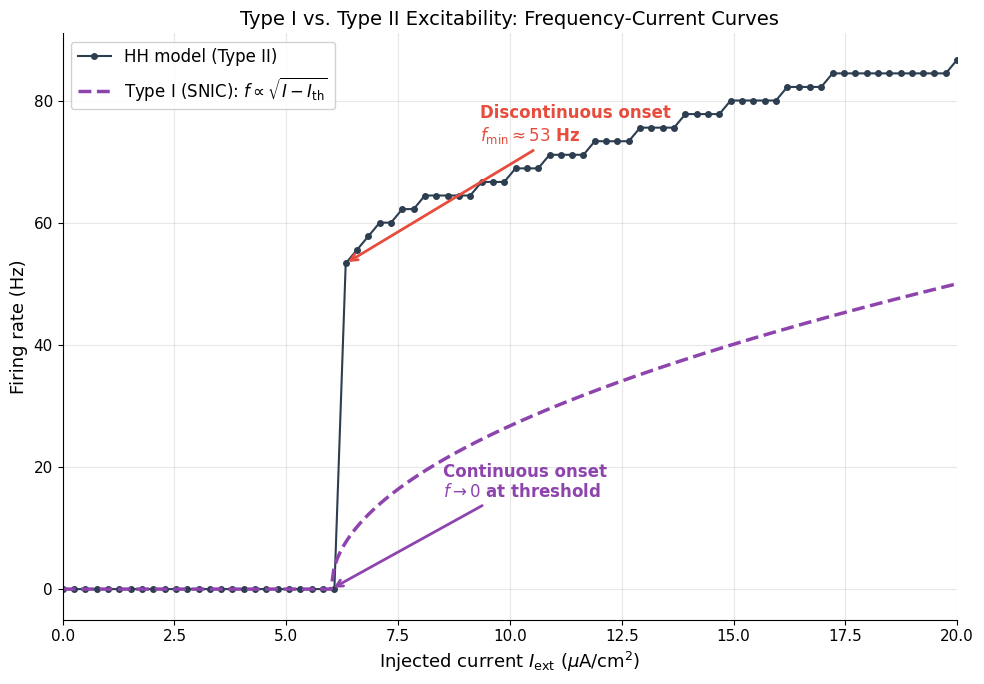

In [23]:
# f-I curve: Type II (HH) vs. Type I (theoretical SNIC) comparison

# Compute HH f-I curve (Type II)
currents_fi, rates_fi = compute_fi_curve_hh(
    I_range=(0.0, 20.0), n_points=80, t_sim=500.0, dt=0.01
)

# Theoretical Type I curve: f proportional to sqrt(I - I_th)
I_th_type1 = 6.0  # hypothetical threshold for Type I neuron
I_type1 = np.linspace(I_th_type1, 20.0, 200)
f_type1 = 50.0 * np.sqrt((I_type1 - I_th_type1) / (20.0 - I_th_type1))

fig, ax = plt.subplots(figsize=(10, 7))

# HH (Type II)
ax.plot(currents_fi, rates_fi, 'o-', color=COLORS['Vm'], markersize=4,
        linewidth=1.5, label='HH model (Type II)')

# Type I theoretical
I_type1_full = np.concatenate([[0, I_th_type1 - 0.01], I_type1])
f_type1_full = np.concatenate([[0, 0], f_type1])
ax.plot(I_type1_full, f_type1_full, '--', color=COLORS['accent'], linewidth=2.5,
        label=r'Type I (SNIC): $f \propto \sqrt{I - I_{\mathrm{th}}}$')

# Find HH threshold
firing_idx = np.where(rates_fi > 0)[0]
if len(firing_idx) > 0:
    I_thresh_hh = currents_fi[firing_idx[0]]
    f_onset_hh = rates_fi[firing_idx[0]]

    # Annotate the discontinuous jump (Type II signature)
    ax.annotate(
        f'Discontinuous onset\n'
        f'$f_{{\\mathrm{{min}}}} \\approx {f_onset_hh:.0f}$ Hz',
        xy=(I_thresh_hh, f_onset_hh), xytext=(I_thresh_hh + 3, f_onset_hh + 20),
        fontsize=12, color=COLORS['Na'], fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=COLORS['Na'], lw=2),
    )

    # Annotate continuous onset (Type I)
    ax.annotate(
        r'Continuous onset' + '\n' + r'$f \to 0$ at threshold',
        xy=(I_th_type1, 0), xytext=(I_th_type1 + 2.5, 15),
        fontsize=12, color=COLORS['accent'], fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=COLORS['accent'], lw=2),
    )

ax.set_xlabel(r'Injected current $I_{\mathrm{ext}}$ ($\mu$A/cm$^2$)', fontsize=13)
ax.set_ylabel('Firing rate (Hz)', fontsize=13)
ax.set_title('Type I vs. Type II Excitability: Frequency-Current Curves',
             fontsize=14)
ax.legend(loc='upper left', fontsize=12, framealpha=0.9)
ax.set_xlim(0, 20)
ax.set_ylim(bottom=-5)

plt.tight_layout()
plt.show()

## 7.4 Hysteresis and Bistability

The subcritical nature of the HH Hopf bifurcation creates a parameter regime where **two stable attractors coexist**: the resting fixed point and the spiking limit cycle. This bistability produces **hysteresis**: the system’s behavior depends not only on the current value of $I_\text{ext}$, but also on its *history*.

Concretely:
- When $I_\text{ext}$ is **ramped up** from zero, firing begins at a current $I_\text{on}$.
- When $I_\text{ext}$ is **ramped down** from a high value, firing persists below $I_\text{on}$ and ceases at a lower current $I_\text{off} < I_\text{on}$.

The difference $I_\text{on} - I_\text{off}$ is the **hysteresis width**, and its existence is a direct consequence of the subcritical bifurcation structure. This phenomenon has been observed experimentally in real neurons and has implications for bistable neural circuits and memory.

C:\Users\jorge.delarosa\AppData\Local\Temp\ipykernel_38508\664981785.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


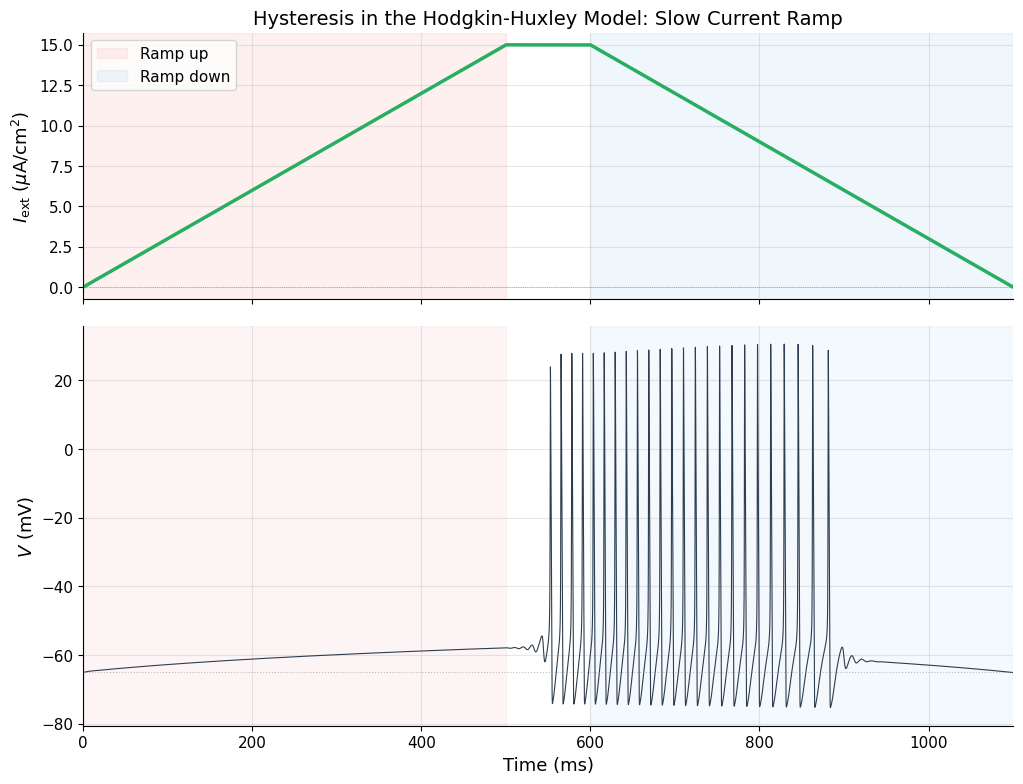

Observe: firing onset (ramp up) and firing cessation (ramp down)
occur at DIFFERENT current values. This is hysteresis.

The current ramp goes from 0 to 15.0 µA/cm² and back to 0.
If the Hopf bifurcation were supercritical, firing would start
and stop at the same current. The subcritical nature of the HH
bifurcation creates a region of bistability.


In [24]:
# Demonstrate hysteresis: slow current ramp up then down

I_max_ramp = 15.0   # peak current
t_ramp = 500.0      # ms for ramp up
t_hold = 100.0      # ms hold at peak
t_down = 500.0      # ms for ramp down
t_total = t_ramp + t_hold + t_down

dt_sim = 0.01
n_steps = int(t_total / dt_sim)
t_arr = np.arange(n_steps) * dt_sim

# Build the ramp current waveform as a numpy array
I_ramp_arr = np.zeros(n_steps)
for k in range(n_steps):
    tk = t_arr[k]
    if tk < t_ramp:
        I_ramp_arr[k] = I_max_ramp * (tk / t_ramp)
    elif tk < t_ramp + t_hold:
        I_ramp_arr[k] = I_max_ramp
    else:
        t_remaining = tk - t_ramp - t_hold
        I_ramp_arr[k] = I_max_ramp * (1.0 - t_remaining / t_down)

t_hyst, y_hyst = hh_solve_current_array(I_ramp_arr, dt_sim)

V_hyst = y_hyst[:, 0]
I_applied = I_ramp_arr

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1.5], 'hspace': 0.08})

# Top panel: applied current
ax1 = axes[0]
ax1.plot(t_hyst, I_applied, color=COLORS['green'], linewidth=2.5)
ax1.set_ylabel(r'$I_{\mathrm{ext}}$ ($\mu$A/cm$^2$)', fontsize=13)
ax1.set_title('Hysteresis in the Hodgkin-Huxley Model: Slow Current Ramp',
              fontsize=14)
ax1.axhline(0, color='gray', linewidth=0.5, linestyle=':')

# Mark ramp-up and ramp-down phases
ax1.axvspan(0, t_ramp, alpha=0.08, color=COLORS['Na'], label='Ramp up')
ax1.axvspan(t_ramp + t_hold, t_total, alpha=0.08, color=COLORS['K'],
            label='Ramp down')
ax1.legend(loc='upper left', fontsize=11)

# Bottom panel: membrane potential
ax2 = axes[1]
ax2.plot(t_hyst, V_hyst, color=COLORS['Vm'], linewidth=0.8)
ax2.set_xlabel('Time (ms)', fontsize=13)
ax2.set_ylabel('$V$ (mV)', fontsize=13)
ax2.axhline(-65, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)

# Color-code the ramp phases
ax2.axvspan(0, t_ramp, alpha=0.05, color=COLORS['Na'])
ax2.axvspan(t_ramp + t_hold, t_total, alpha=0.05, color=COLORS['K'])

ax2.set_xlim(0, t_total)

plt.tight_layout()
plt.show()

print('Observe: firing onset (ramp up) and firing cessation (ramp down)')
print('occur at DIFFERENT current values. This is hysteresis.')
print(f'\nThe current ramp goes from 0 to {I_max_ramp} µA/cm² and back to 0.')
print('If the Hopf bifurcation were supercritical, firing would start')
print('and stop at the same current. The subcritical nature of the HH')
print('bifurcation creates a region of bistability.')

### Summary of Dynamical Systems Analysis

We have now established the complete dynamical systems picture of the Hodgkin-Huxley model:

1. **Phase plane reduction**: By exploiting the timescale separation ($m$ fast, $n$ and $h$ slow) and the approximate linear relationship $h \approx 0.83 - n$, we reduced the 4D HH system to a 2D system in the $(V, n)$ plane.

2. **Nullclines and fixed points**: The $V$-nullcline has an N-shaped (cubic-like) profile, and the $n$-nullcline is a monotone sigmoid. Their intersection determines the fixed point. As $I_\text{ext}$ increases, the $V$-nullcline shifts upward, moving the fixed point along the nullclines.

3. **Linear stability**: The Jacobian eigenvalues reveal that the resting state is a **stable spiral** at low currents. As $I_\text{ext}$ increases, the real parts of complex eigenvalue pairs cross zero; a **Hopf bifurcation**.

4. **Subcritical Hopf**: The bifurcation is subcritical, meaning firing onset is **discontinuous** (Type II excitability) and the system exhibits **hysteresis** (bistability between rest and spiking).

5. **Type II excitability**: The f-I curve starts at a nonzero frequency, in contrast to Type I neurons (SNIC bifurcation) that can fire arbitrarily slowly. This reflects the biophysical properties of the HH model’s ionic currents.

These results illustrate a profound principle: **the qualitative behavior of a neural model is determined by its bifurcation structure**, not by its specific biophysical details. Different ionic mechanisms can produce the same type of bifurcation (and hence the same firing phenomenology), while changes in a single parameter can switch the system between fundamentally different dynamical regimes.

---

# 8. The Leaky Integrate-and-Fire Model

## 8.1 From Biophysics to Simplicity

The Hodgkin-Huxley model is a triumph of mathematical biophysics, but it comes at a cost: **four coupled nonlinear ODEs** that require careful numerical integration with small time steps. For many applications in computational neuroscience (large-scale network simulations, machine learning with spiking neurons, theoretical analysis of neural coding) this level of detail is neither necessary nor computationally feasible.

The **Leaky Integrate-and-Fire (LIF)** model occupies the opposite end of the realism-tractability spectrum. It retains the essential feature of neural computation (spike generation through threshold crossing) while discarding all voltage-dependent conductance dynamics. The result is a **single linear ODE** with a discontinuous reset rule: orders of magnitude cheaper to simulate, and often analytically solvable.

The fundamental trade-off:

| Property | Hodgkin-Huxley | LIF |
|:---|:---|:---|
| State variables | 4 ($V, n, m, h$) | 1 ($V$) |
| ODE type | Nonlinear, coupled | Linear, scalar |
| Spike mechanism | Emergent from ion channels | Imposed threshold rule |
| Computational cost per spike | High | Very low |
| Analytical tractability | Limited | Extensive |

## 8.2 Derivation from RC Circuit

Strip the membrane down to its simplest form: a **passive RC circuit**. No voltage-dependent conductances, no gating variables: just a capacitor (the lipid bilayer) in parallel with a resistor (the combined leak conductance):

$$C_m \frac{dV}{dt} = -\frac{V - V_\text{rest}}{R_m} + I_\text{ext}$$

where $R_m$ is the membrane resistance (inverse of the total leak conductance) and $V_\text{rest}$ is the resting potential. Defining the **membrane time constant** $\tau_m = R_m C_m$, we obtain the standard LIF equation:

$$\tau_m \frac{dV}{dt} = -(V - V_\text{rest}) + R_m I_\text{ext}$$

This is a **linear first-order ODE** (unlike the HH system, which is nonlinear!). For constant $I_\text{ext}$, the analytical solution exists in closed form:

$$V(t) = V_\text{rest} + R_m I_\text{ext}\left(1 - e^{-t/\tau_m}\right)$$

The voltage exponentially approaches the asymptotic value $V_\infty = V_\text{rest} + R_m I_\text{ext}$ with time constant $\tau_m$. If $V_\infty < V_\text{th}$, the neuron never fires (subthreshold regime). If $V_\infty \geq V_\text{th}$, the voltage will reach threshold in finite time, and we need the fire-and-reset rule.

## 8.3 The Fire-and-Reset Rule

The RC circuit alone does not spike: it merely charges toward an asymptote. To produce discrete spike events, we impose a **discontinuous threshold rule**:

> When $V \geq V_\text{th}$: **(1)** record a spike at time $t_\text{spike}$, **(2)** reset $V \to V_\text{reset}$, **(3)** enforce an absolute refractory period $t_\text{ref}$ during which the voltage is clamped at $V_\text{reset}$.

The spike itself has **no shape** in the LIF model: it is a mathematical point event (a Dirac delta function in the spike train). This is the most fundamental difference from the HH model, where the action potential waveform emerges naturally from the ionic current dynamics.

**Default parameters:**

| Parameter | Symbol | Value | Units |
|:---|:---|:---|:---|
| Resting potential | $V_\text{rest}$ | $-65$ | mV |
| Membrane time constant | $\tau_m$ | $10$ | ms |
| Membrane resistance | $R_m$ | $10$ | M$\Omega$ |
| Spike threshold | $V_\text{th}$ | $-50$ | mV |
| Reset potential | $V_\text{reset}$ | $-65$ | mV |
| Refractory period | $t_\text{ref}$ | $2$ | ms |

The threshold current (rheobase) is $I_\text{rheo} = (V_\text{th} - V_\text{rest}) / R_m = 15/10 = 1.5$ nA.

## 8.4 LIF Implementation and Simulation

Let us simulate the LIF model using the `lif_simulate` function from our package and visualize the characteristic **sawtooth waveform** of the LIF membrane potential.

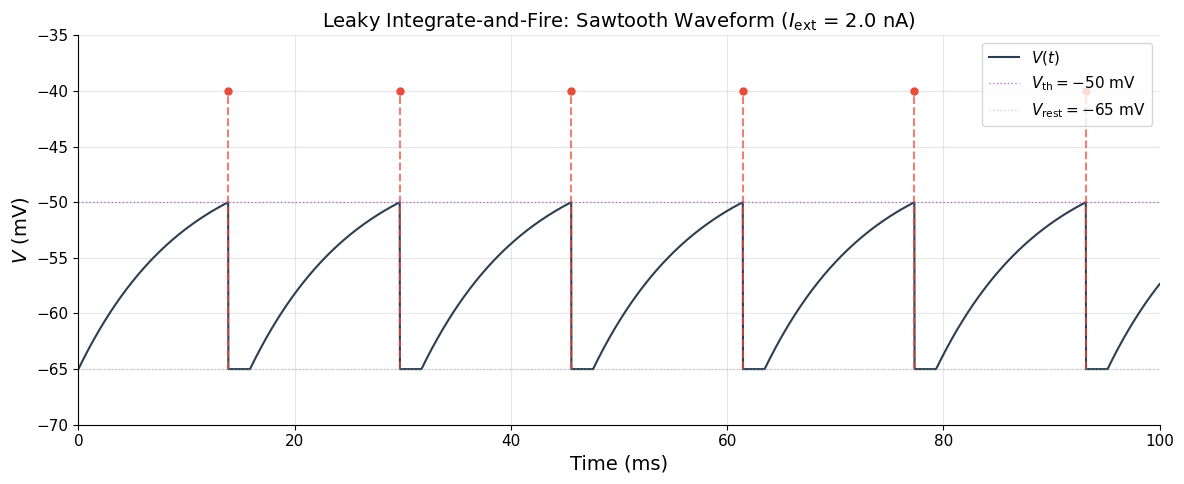

Number of spikes: 6
Mean ISI: 15.87 ms
Firing rate: 63.0 Hz


In [25]:
# Import LIF components and additional tools
from neural_dynamics import lif_simulate, LIF_DEFAULT_PARAMS, compute_fi_curve_hh
import numba as nb
import time

# Simulate LIF with constant suprathreshold current
I_ext_lif = 2.0   # nA (above rheobase of 1.5 nA)
t_end = 100.0      # ms
dt_lif = 0.01      # ms

t_lif, V_lif, spike_idx = lif_simulate(I_ext_lif, t_end, dt_lif)

fig, ax = plt.subplots(figsize=(12, 5))

# Plot membrane potential
ax.plot(t_lif, V_lif, color=COLORS['Vm'], linewidth=1.5, label='$V(t)$')

# Mark spike times with vertical lines and dots
for si in spike_idx:
    ax.plot([t_lif[si], t_lif[si]], [V_lif[si], -40.0],
            color=COLORS['Na'], linewidth=1.5, linestyle='--', alpha=0.7)
    ax.plot(t_lif[si], -40.0, 'o', color=COLORS['Na'], markersize=5, zorder=5)

# Reference lines
ax.axhline(-50.0, color=COLORS['accent'], linewidth=1, linestyle=':', alpha=0.7,
           label=r'$V_{\mathrm{th}} = -50$ mV')
ax.axhline(-65.0, color=COLORS['leak'], linewidth=1, linestyle=':', alpha=0.5,
           label=r'$V_{\mathrm{rest}} = -65$ mV')

ax.set_xlabel('Time (ms)')
ax.set_ylabel('$V$ (mV)')
ax.set_title(f'Leaky Integrate-and-Fire: Sawtooth Waveform ($I_{{\\mathrm{{ext}}}}$ = {I_ext_lif} nA)',
             fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim(0, t_end)
ax.set_ylim(-70, -35)

plt.tight_layout()
plt.show()

n_spikes = len(spike_idx)
if n_spikes > 1:
    isi = np.mean(np.diff(t_lif[spike_idx]))
    freq = 1000.0 / isi
    print(f"Number of spikes: {n_spikes}")
    print(f"Mean ISI: {isi:.2f} ms")
    print(f"Firing rate: {freq:.1f} Hz")
else:
    print(f"Number of spikes: {n_spikes}")

C:\Users\jorge.delarosa\AppData\Local\Temp\ipykernel_38508\287271977.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


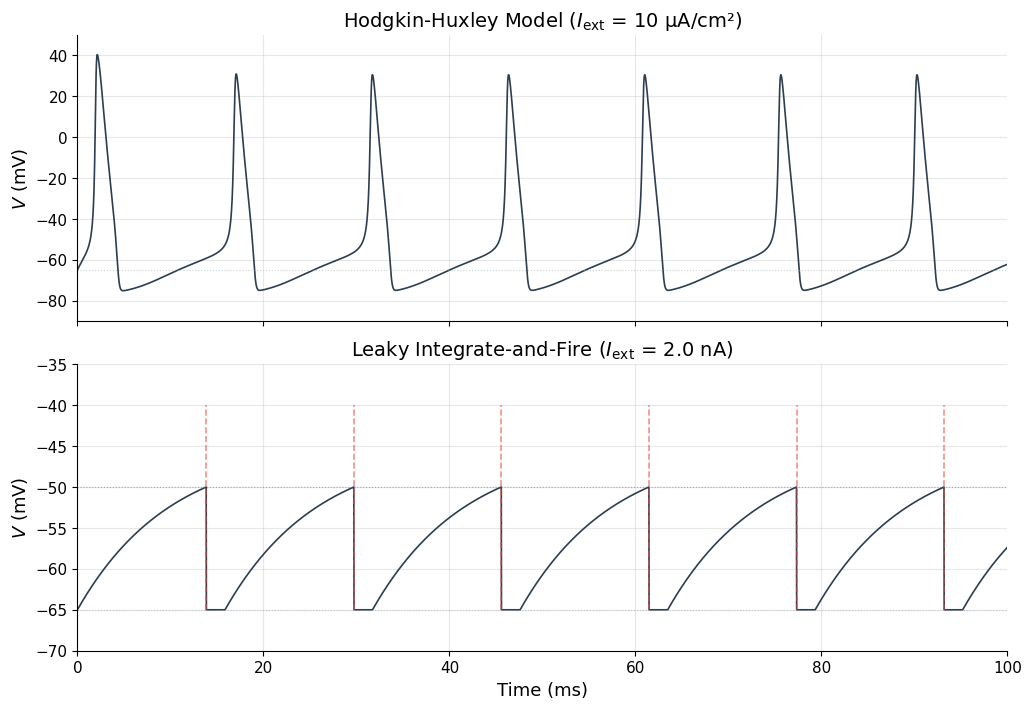

Key differences visible in the plots:
  HH: biophysical spike shape with overshoot (+40 mV) and undershoot (-80 mV)
  LIF: linear ramp to threshold, instantaneous reset, no spike waveform
  HH: natural refractory period from Na+ inactivation
  LIF: imposed absolute refractory period (voltage clamped at V_reset)


In [26]:
# Side-by-side comparison: HH vs LIF for the same stimulation protocol

# HH simulation with constant I_ext = 10 uA/cm^2
t_hh, y_hh = hh_solve_constant(10.0, 100.0, 0.01)
V_hh = y_hh[:, 0]

# LIF simulation with I_ext = 2 nA (both are suprathreshold for their models)
t_lif2, V_lif2, spk_lif2 = lif_simulate(2.0, 100.0, 0.01)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={'hspace': 0.15})

# Top: HH
ax1 = axes[0]
ax1.plot(t_hh, V_hh, color=COLORS['Vm'], linewidth=1.2)
ax1.set_ylabel('$V$ (mV)', fontsize=13)
ax1.set_title('Hodgkin-Huxley Model ($I_{\\mathrm{ext}}$ = 10 µA/cm²)',
              fontsize=14)
ax1.set_ylim(-90, 50)
ax1.axhline(-65, color=COLORS['leak'], linewidth=0.8, linestyle=':', alpha=0.5)

# Bottom: LIF
ax2 = axes[1]
ax2.plot(t_lif2, V_lif2, color=COLORS['Vm'], linewidth=1.2)
for si in spk_lif2:
    ax2.plot([t_lif2[si], t_lif2[si]], [V_lif2[si], -40.0],
             color=COLORS['Na'], linewidth=1.2, linestyle='--', alpha=0.6)
ax2.set_xlabel('Time (ms)', fontsize=13)
ax2.set_ylabel('$V$ (mV)', fontsize=13)
ax2.set_title('Leaky Integrate-and-Fire ($I_{\\mathrm{ext}}$ = 2.0 nA)',
              fontsize=14)
ax2.set_ylim(-70, -35)
ax2.axhline(-50, color=COLORS['accent'], linewidth=0.8, linestyle=':', alpha=0.5)
ax2.axhline(-65, color=COLORS['leak'], linewidth=0.8, linestyle=':', alpha=0.5)

ax1.set_xlim(0, 100)
plt.tight_layout()
plt.show()

print("Key differences visible in the plots:")
print("  HH: biophysical spike shape with overshoot (+40 mV) and undershoot (-80 mV)")
print("  LIF: linear ramp to threshold, instantaneous reset, no spike waveform")
print("  HH: natural refractory period from Na+ inactivation")
print("  LIF: imposed absolute refractory period (voltage clamped at V_reset)")

## 8.5 What LIF Discards

The simplification from HH to LIF comes at a significant cost in biophysical detail:

1. **No spike shape.** In HH, the action potential waveform (rapid depolarization, overshoot to +40 mV, repolarization, undershoot to -80 mV) emerges from the interplay of Na$^+$ and K$^+$ currents. In LIF, the spike is a dimensionless point event; the voltage jumps discontinuously from $V_\text{th}$ to $V_\text{reset}$.

2. **No Na$^+$ dynamics or inactivation.** The rapid activation and subsequent inactivation of sodium channels (the mechanism that terminates the action potential) is entirely absent. There is no gating variable $m$ or $h$.

3. **No natural refractory period.** In HH, the refractory period arises naturally from Na$^+$ channel inactivation ($h \to 0$) and K$^+$ channel activation ($n \to 1$). In LIF, refractoriness must be imposed artificially as a hard-coded time window.

4. **No subthreshold nonlinearities.** The HH model exhibits rich subthreshold dynamics: resonance, subthreshold oscillations, and a voltage-dependent effective time constant. The LIF subthreshold dynamics are purely linear.

5. **No anode break excitation.** The post-inhibitory rebound spike we observed in the HH model (Section 5.5) relies on the differential recovery rates of Na$^+$ and K$^+$ channels. LIF cannot exhibit this phenomenon.

Despite these limitations, the LIF model captures the essential feature of neural spiking (**threshold-triggered discrete events**) and does so with remarkable efficiency. In the next section, we quantify exactly how the two models compare.

---

# 9. Quantitative Comparison: HH vs LIF

Having introduced both models, we now compare them head-to-head on four quantitative dimensions: firing rate, spike shape, refractory behavior, and computational cost.

## 9.1 Firing Rate Comparison: f-I Curves

The frequency-current (f-I) curve is the single most important input-output characterization of a neuron model. It reveals the neuron's **excitability type**: Type I neurons can fire at arbitrarily low rates (continuous onset), while Type II neurons begin firing at a nonzero minimum frequency (discontinuous onset).

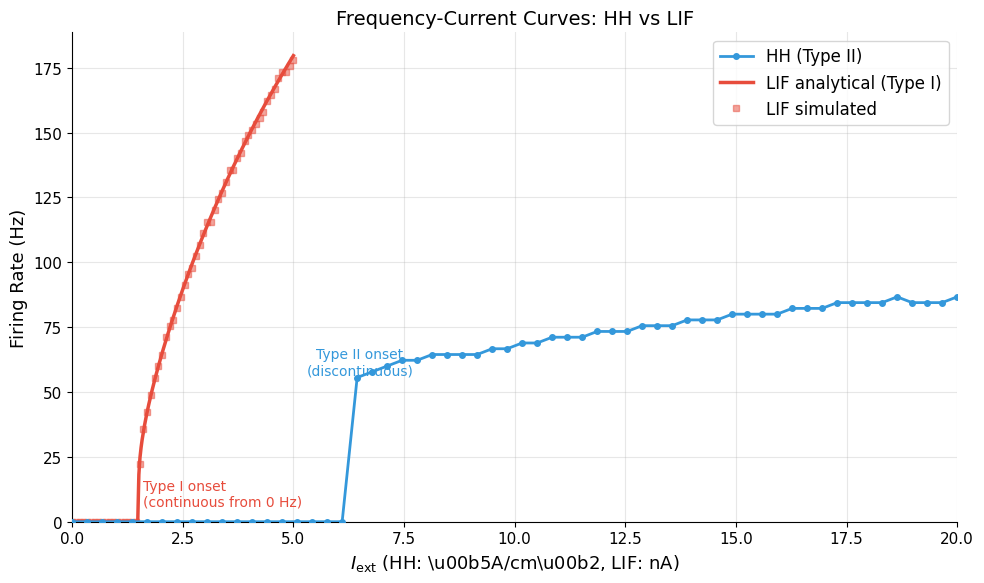

LIF rheobase current: 1.50 nA
Note: HH and LIF use different current units (µA/cm² vs nA).
The key qualitative difference: HH starts firing at a NONZERO frequency
(Type II, Hopf bifurcation), while LIF firing rate rises continuously
from 0 Hz (Type I, no bifurcation, just a threshold).


In [27]:
# f-I curves: HH (Type II) vs LIF (Type I), overlaid

# --- HH f-I curve ---
I_range_hh = (0.0, 20.0)
n_pts = 60
currents_hh, rates_hh = compute_fi_curve_hh(I_range_hh, n_pts, t_sim=500.0, dt=0.01)

# --- LIF f-I curve (analytical) ---
V_rest_lif, tau_m_lif, R_m_lif, V_th_lif, V_reset_lif, t_ref_lif = LIF_DEFAULT_PARAMS
I_rheo = (V_th_lif - V_rest_lif) / R_m_lif  # rheobase current

I_lif = np.linspace(0.0, 5.0, 200)
f_lif = np.zeros_like(I_lif)
for i, I in enumerate(I_lif):
    V_inf = R_m_lif * I  # effective driving force above V_rest
    if V_inf > (V_th_lif - V_rest_lif):  # suprathreshold
        # Time to threshold: tau_m * ln(R_m*I / (R_m*I - (V_th - V_rest)))
        t_to_th = tau_m_lif * np.log(V_inf / (V_inf - (V_th_lif - V_rest_lif)))
        isi = t_ref_lif + t_to_th  # ms
        f_lif[i] = 1000.0 / isi   # Hz

# --- LIF f-I curve (simulation, for validation) ---
I_lif_sim = np.linspace(0.0, 5.0, 60)
f_lif_sim = np.zeros_like(I_lif_sim)
for i, I in enumerate(I_lif_sim):
    t_s, V_s, spk_s = lif_simulate(float(I), 500.0, 0.01)
    # Skip first 50 ms transient
    skip = int(50.0 / 0.01)
    spike_times = t_s[spk_s[spk_s >= skip]] if len(spk_s) > 0 else np.array([])
    n_sp = len(spike_times)
    t_window = (500.0 - 50.0) / 1000.0  # seconds
    f_lif_sim[i] = n_sp / t_window if t_window > 0 else 0.0

fig, ax = plt.subplots(figsize=(10, 6))

# HH curve
ax.plot(currents_hh, rates_hh, 'o-', color=COLORS['K'], markersize=4,
        linewidth=2, label='HH (Type II)', zorder=3)

# LIF analytical
ax.plot(I_lif, f_lif, '-', color=COLORS['Na'], linewidth=2.5,
        label='LIF analytical (Type I)')

# LIF simulated (validation dots)
ax.plot(I_lif_sim, f_lif_sim, 's', color=COLORS['Na'], markersize=4,
        alpha=0.5, label='LIF simulated', zorder=2)

ax.set_xlabel(r'$I_{\mathrm{ext}}$ (HH: \u00b5A/cm\u00b2, LIF: nA)', fontsize=13)
ax.set_ylabel('Firing Rate (Hz)', fontsize=13)
ax.set_title('Frequency-Current Curves: HH vs LIF', fontsize=14)
ax.legend(fontsize=12)
ax.set_xlim(0, 20)
ax.set_ylim(0, None)

# Add annotations
ax.annotate('Type II onset\n(discontinuous)',
            xy=(6.5, rates_hh[rates_hh > 0][0] if np.any(rates_hh > 0) else 50),
            fontsize=10, color=COLORS['K'],
            ha='center', va='bottom')
ax.annotate('Type I onset\n(continuous from 0 Hz)',
            xy=(I_rheo + 0.1, 5), fontsize=10, color=COLORS['Na'],
            ha='left', va='bottom')

plt.tight_layout()
plt.show()

print(f"LIF rheobase current: {I_rheo:.2f} nA")
print(f"Note: HH and LIF use different current units (\u00b5A/cm\u00b2 vs nA).")
print(f"The key qualitative difference: HH starts firing at a NONZERO frequency")
print(f"(Type II, Hopf bifurcation), while LIF firing rate rises continuously")
print(f"from 0 Hz (Type I, no bifurcation, just a threshold).")

## 9.2 Spike Shape Comparison

A single spike reveals the most striking qualitative difference between the two models.

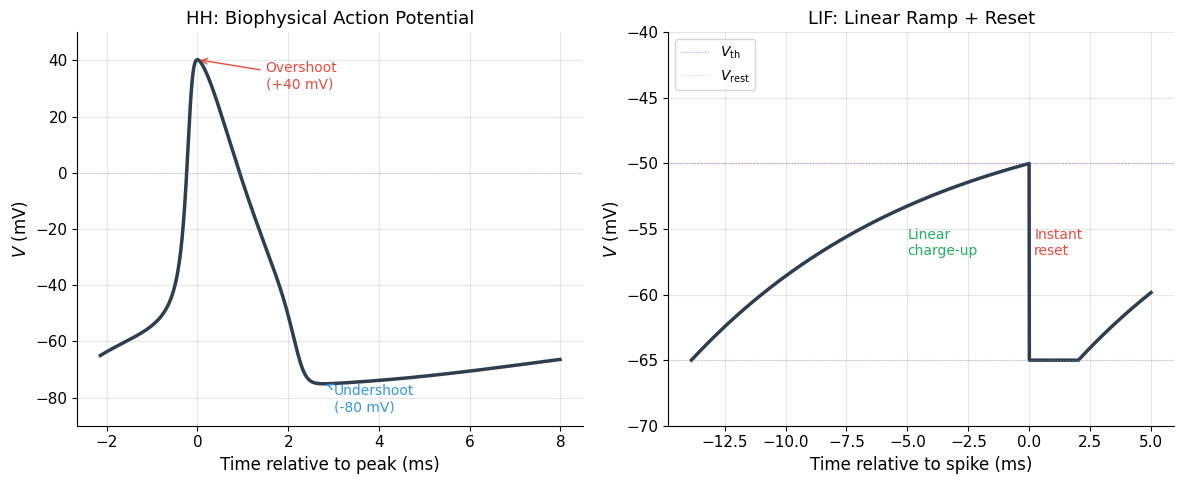

Left: HH spike takes ~1 ms for the upstroke and ~3 ms to repolarize.
      The overshoot (+40 mV) and undershoot (-80 mV) reflect Na+/K+ dynamics.
Right: LIF has no spike shape. Voltage ramps linearly to threshold,
       then resets instantaneously. No overshoot, no undershoot.


In [28]:
# Zoom into a single spike from each model

# HH: extract a single spike (use the 10 uA/cm^2 simulation from above)
# Find the first spike peak
spike_peaks_hh = []
for i in range(1, len(V_hh) - 1):
    if V_hh[i] > 0 and V_hh[i] > V_hh[i-1] and V_hh[i] >= V_hh[i+1]:
        spike_peaks_hh.append(i)
        break

if spike_peaks_hh:
    pk = spike_peaks_hh[0]
    # Window: 3 ms before peak to 8 ms after
    i_start = max(0, pk - int(3.0 / 0.01))
    i_end = min(len(t_hh), pk + int(8.0 / 0.01))
    t_spike_hh = t_hh[i_start:i_end] - t_hh[pk]  # center on peak
    V_spike_hh = V_hh[i_start:i_end]

# LIF: extract a single spike (ramp up to threshold + reset)
if len(spk_lif2) > 0:
    si = spk_lif2[0]
    # Window: look back to find where the ramp started (after previous refractory)
    ramp_start = max(0, si - int(15.0 / 0.01))
    ramp_end = min(len(t_lif2), si + int(5.0 / 0.01))
    t_spike_lif = t_lif2[ramp_start:ramp_end] - t_lif2[si]
    V_spike_lif = V_lif2[ramp_start:ramp_end]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: HH spike
ax1 = axes[0]
ax1.plot(t_spike_hh, V_spike_hh, color=COLORS['Vm'], linewidth=2.5)
ax1.axhline(0, color=COLORS['leak'], linewidth=0.8, linestyle=':', alpha=0.5)
ax1.set_xlabel('Time relative to peak (ms)', fontsize=12)
ax1.set_ylabel('$V$ (mV)', fontsize=12)
ax1.set_title('HH: Biophysical Action Potential', fontsize=13)
ax1.set_ylim(-90, 50)
ax1.annotate('Overshoot\n(+40 mV)', xy=(0, V_spike_hh.max()),
             xytext=(1.5, 30), fontsize=10, color=COLORS['Na'],
             arrowprops=dict(arrowstyle='->', color=COLORS['Na']))
undershoot_idx = np.argmin(V_spike_hh[int(2.0/0.01):]) + int(2.0/0.01)
ax1.annotate('Undershoot\n(-80 mV)', xy=(t_spike_hh[undershoot_idx], V_spike_hh[undershoot_idx]),
             xytext=(3, -85), fontsize=10, color=COLORS['K'],
             arrowprops=dict(arrowstyle='->', color=COLORS['K']))

# Right: LIF spike
ax2 = axes[1]
ax2.plot(t_spike_lif, V_spike_lif, color=COLORS['Vm'], linewidth=2.5)
ax2.axhline(-50, color=COLORS['accent'], linewidth=0.8, linestyle=':', alpha=0.6,
            label=r'$V_{\mathrm{th}}$')
ax2.axhline(-65, color=COLORS['leak'], linewidth=0.8, linestyle=':', alpha=0.5,
            label=r'$V_{\mathrm{rest}}$')
ax2.set_xlabel('Time relative to spike (ms)', fontsize=12)
ax2.set_ylabel('$V$ (mV)', fontsize=12)
ax2.set_title('LIF: Linear Ramp + Reset', fontsize=13)
ax2.set_ylim(-70, -40)
ax2.legend(loc='upper left', fontsize=10)

# Annotate the LIF features
ax2.annotate('Linear\ncharge-up', xy=(-5, -57), fontsize=10, color=COLORS['green'])
ax2.annotate('Instant\nreset', xy=(0.2, -57), fontsize=10, color=COLORS['Na'])

plt.tight_layout()
plt.show()

print("Left: HH spike takes ~1 ms for the upstroke and ~3 ms to repolarize.")
print("      The overshoot (+40 mV) and undershoot (-80 mV) reflect Na+/K+ dynamics.")
print("Right: LIF has no spike shape. Voltage ramps linearly to threshold,")
print("       then resets instantaneously. No overshoot, no undershoot.")

## 9.3 Refractory Period Comparison

In the HH model, the refractory period emerges naturally from the slow recovery of Na$^+$ inactivation ($h$) and the slow deactivation of K$^+$ channels ($n$). The recovery is **continuous**: at short interpulse intervals, the second spike is smaller and slower; at longer intervals, it gradually recovers to full amplitude.

In the LIF model, the refractory period is a **binary switch**: during $t_\text{ref}$, the neuron is completely unable to fire; after $t_\text{ref}$, it fires with exactly the same characteristics as before.

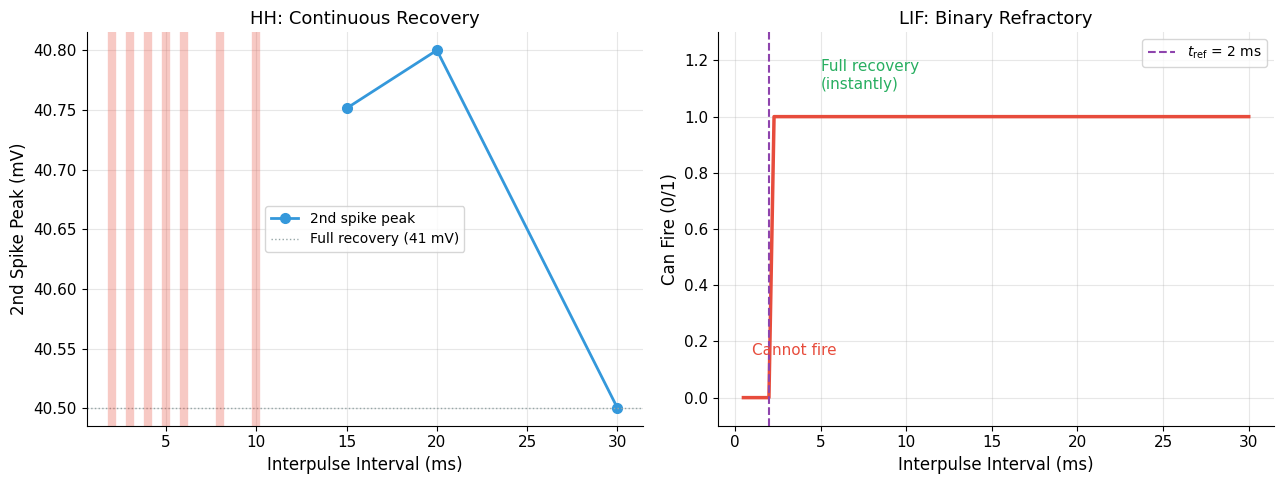

HH: the second spike amplitude recovers CONTINUOUSLY over ~10-15 ms.
     At very short intervals (< 3 ms), no second spike is possible (absolute refractory).
     At intermediate intervals, the spike is smaller (relative refractory).
LIF: recovery is a STEP FUNCTION at t_ref. Before t_ref: impossible.
     After t_ref: full, identical response. No graded recovery.


In [29]:
# Paired-pulse refractory experiment: HH vs LIF

# --- HH paired-pulse ---
delays_hh = np.array([2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 15.0, 20.0, 30.0])
second_spike_amp_hh = np.full(len(delays_hh), np.nan)

dt_sim = 0.01
I_val = 20.0  # strong pulse to guarantee spike

for idx, delay in enumerate(delays_hh):
    t_total_pp = 10.0 + delay + 10.0  # pre + delay + post
    n_steps_pp = int(t_total_pp / dt_sim)
    pulse_end1 = 2.0
    pulse_start2 = 1.0 + delay
    pulse_end2 = pulse_start2 + 1.0

    I_ext = np.zeros(n_steps_pp)
    I_ext[int(1.0 / dt_sim):int(pulse_end1 / dt_sim)] = I_val
    I_ext[int(pulse_start2 / dt_sim):int(pulse_end2 / dt_sim)] = I_val

    t_pp, y_pp = hh_solve_current_array(I_ext, dt_sim)
    V_pp = y_pp[:, 0]

    # Find spike peaks (V > -20 and local max)
    peaks = []
    for i in range(1, len(V_pp) - 1):
        if V_pp[i] > -20 and V_pp[i] > V_pp[i-1] and V_pp[i] >= V_pp[i+1]:
            # Avoid counting the same spike twice
            if len(peaks) == 0 or (t_pp[i] - t_pp[peaks[-1]]) > 1.0:
                peaks.append(i)

    if len(peaks) >= 2:
        second_spike_amp_hh[idx] = V_pp[peaks[1]]
    elif len(peaks) == 1:
        second_spike_amp_hh[idx] = np.nan  # no second spike

# --- LIF paired-pulse ---
# In LIF, after t_ref the neuron can fire with exactly the same properties
# So the recovery is a step function
delays_lif = np.linspace(0.5, 30.0, 100)
can_fire_lif = np.zeros(len(delays_lif))
for i, d in enumerate(delays_lif):
    if d >= LIF_DEFAULT_PARAMS[5]:  # t_ref
        can_fire_lif[i] = 1.0
    else:
        can_fire_lif[i] = 0.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: HH recovery curve
ax1 = axes[0]
valid = ~np.isnan(second_spike_amp_hh)
ax1.plot(delays_hh[valid], second_spike_amp_hh[valid], 'o-', color=COLORS['K'],
         linewidth=2, markersize=7, label='2nd spike peak')

# Mark where first spike peak is (reference)
first_spike_peak = second_spike_amp_hh[valid][-1] if np.any(valid) else 40.0
ax1.axhline(first_spike_peak, color=COLORS['leak'], linewidth=1, linestyle=':',
            label=f'Full recovery ({first_spike_peak:.0f} mV)')

# Mark no-spike delays
no_spike = np.isnan(second_spike_amp_hh)
for d in delays_hh[no_spike]:
    ax1.axvline(d, color=COLORS['Na'], alpha=0.3, linewidth=6)

ax1.set_xlabel('Interpulse Interval (ms)', fontsize=12)
ax1.set_ylabel('2nd Spike Peak (mV)', fontsize=12)
ax1.set_title('HH: Continuous Recovery', fontsize=13)
ax1.legend(fontsize=10)
if np.any(no_spike):
    ax1.annotate('No 2nd spike\n(absolute refractory)',
                 xy=(delays_hh[no_spike][0], -20),
                 fontsize=10, color=COLORS['Na'], ha='center')

# Right: LIF binary recovery
ax2 = axes[1]
ax2.plot(delays_lif, can_fire_lif, '-', color=COLORS['Na'], linewidth=2.5)
ax2.axvline(LIF_DEFAULT_PARAMS[5], color=COLORS['accent'], linewidth=1.5, linestyle='--',
            label=f'$t_{{\\mathrm{{ref}}}}$ = {LIF_DEFAULT_PARAMS[5]:.0f} ms')
ax2.set_xlabel('Interpulse Interval (ms)', fontsize=12)
ax2.set_ylabel('Can Fire (0/1)', fontsize=12)
ax2.set_title('LIF: Binary Refractory', fontsize=13)
ax2.set_ylim(-0.1, 1.3)
ax2.legend(fontsize=10)
ax2.annotate('Cannot fire', xy=(1.0, 0.15), fontsize=11, color=COLORS['Na'])
ax2.annotate('Full recovery\n(instantly)', xy=(5.0, 1.1), fontsize=11, color=COLORS['green'])

plt.tight_layout()
plt.show()

print("HH: the second spike amplitude recovers CONTINUOUSLY over ~10-15 ms.")
print("     At very short intervals (< 3 ms), no second spike is possible (absolute refractory).")
print("     At intermediate intervals, the spike is smaller (relative refractory).")
print("LIF: recovery is a STEP FUNCTION at t_ref. Before t_ref: impossible.")
print("     After t_ref: full, identical response. No graded recovery.")

## 9.4 Computational Cost Benchmark

For network simulations involving thousands of neurons, computational cost per neuron is critical. Here we benchmark 10 seconds of simulation time for each model and method combination.

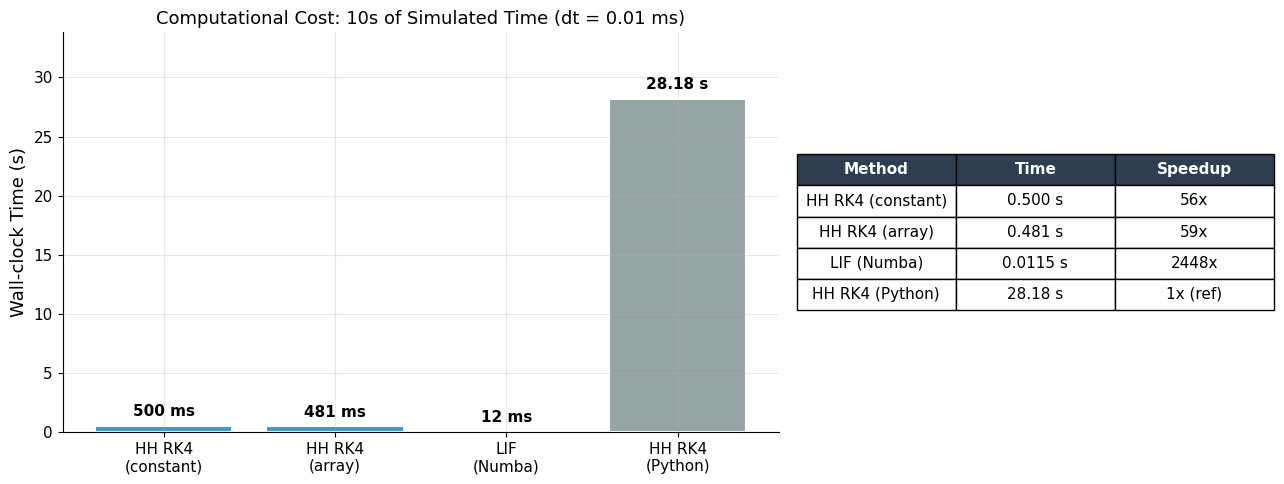


Key findings:
  LIF is ~43x faster than HH RK4 (both Numba-compiled)
  Numba compilation gives ~56x speedup for HH RK4
  For a network of 10,000 neurons for 10s:
    HH RK4 (Numba): ~1.4 hours
    LIF (Numba):    ~0.0 hours


In [30]:
# Computational cost benchmark: HH vs LIF

# --- Warm up Numba JIT for all paths ---
_ = hh_solve_constant(10.0, 10.0, 0.01)
_ = lif_simulate(2.0, 10.0, 0.01)

t_sim_bench = 10000.0  # 10 seconds in ms
dt_bench = 0.01
n_runs = 5

# --- HH with RK4 (Numba) via hh_solve_constant ---
times_hh_rk4 = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    hh_solve_constant(10.0, t_sim_bench, dt_bench)
    times_hh_rk4.append(time.perf_counter() - t0)
t_hh_rk4 = np.median(times_hh_rk4)

# --- HH with RK4 (Numba) via current array ---
n_steps_bench = int(t_sim_bench / dt_bench)
I_bench_arr = np.full(n_steps_bench, 10.0)
_ = hh_solve_current_array(I_bench_arr, dt_bench) # warm up
times_hh_arr = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    hh_solve_current_array(I_bench_arr, dt_bench)
    times_hh_arr.append(time.perf_counter() - t0)
t_hh_arr = np.median(times_hh_arr)

# --- LIF (Numba) ---
times_lif = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    lif_simulate(2.0, t_sim_bench, dt_bench)
    times_lif.append(time.perf_counter() - t0)
t_lif_bench = np.median(times_lif)

# --- HH with RK4 (Pure Python, no Numba) ---
def hh_rhs_python(t, y, I_ext=10.0):
    "Pure Python HH RHS (no Numba)."
    V, n, m, h = y
    C_m, g_Na, g_K, g_L, E_Na, E_K, E_L = 1.0, 120.0, 36.0, 0.3, 50.0, -77.0, -54.4

    dV_v = V + 55.0
    a_n = 0.01 * dV_v / (1.0 - np.exp(-dV_v / 10.0)) if abs(dV_v) > 1e-7 else 0.1
    b_n = 0.125 * np.exp(-(V + 65.0) / 80.0)

    dV_m = V + 40.0
    a_m = 0.1 * dV_m / (1.0 - np.exp(-dV_m / 10.0)) if abs(dV_m) > 1e-7 else 1.0
    b_m = 4.0 * np.exp(-(V + 65.0) / 18.0)

    a_h = 0.07 * np.exp(-(V + 65.0) / 20.0)
    b_h = 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))

    I_Na = g_Na * m**3 * h * (V - E_Na)
    I_K = g_K * n**4 * (V - E_K)
    I_L = g_L * (V - E_L)

    return [
       (I_ext - I_Na - I_K - I_L) / C_m,
        a_n * (1.0 - n) - b_n * n,
        a_m * (1.0 - m) - b_m * m,
        a_h * (1.0 - h) - b_h * h,
    ]

def rk4_python(rhs, y, t, dt):
    "Pure Python RK4 step."
    k1 = rhs(t, y)
    k2 = rhs(t + 0.5*dt, [y[j] + 0.5*dt*k1[j] for j in range(4)])
    k3 = rhs(t + 0.5*dt, [y[j] + 0.5*dt*k2[j] for j in range(4)])
    k4 = rhs(t + dt, [y[j] + dt*k3[j] for j in range(4)])
    return [y[j] + (dt/6.0)*(k1[j] + 2*k2[j] + 2*k3[j] + k4[j]) for j in range(4)]

# Only simulate 1 second for pure Python (it is very slow)
t_sim_py = 1000.0  # 1 second in ms
n_steps_py = int(t_sim_py / dt_bench)
t0 = time.perf_counter()
y_py = [-65.0, 0.3177, 0.0529, 0.5961]
t_current = 0.0
for _ in range(n_steps_py):
    y_py = rk4_python(hh_rhs_python, y_py, t_current, dt_bench)
    t_current += dt_bench
t_hh_python = (time.perf_counter() - t0) * 10.0  # extrapolate to 10 seconds

# --- Results ---
methods = ['HH RK4\n(constant)', 'HH RK4\n(array)', 'LIF\n(Numba)', 'HH RK4\n(Python)']
times_all = [t_hh_rk4, t_hh_arr, t_lif_bench, t_hh_python]
colors_bar = [COLORS['K'], COLORS['K'], COLORS['Na'], COLORS['leak']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={'width_ratios': [1.5, 1]})

# Bar chart
ax1 = axes[0]
bars = ax1.bar(methods, times_all, color=colors_bar, edgecolor='white', linewidth=1.5)
ax1.set_ylabel('Wall-clock Time (s)', fontsize=13)
ax1.set_title('Computational Cost: 10s of Simulated Time (dt = 0.01 ms)', fontsize=13)

# Add time labels on bars
for bar, t_val in zip(bars, times_all):
    height = bar.get_height()
    if t_val < 1.0:
        label = f'{t_val*1000:.0f} ms'
    else:
        label = f'{t_val:.2f} s'
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(times_all)*0.02,
             label, ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylim(0, max(times_all) * 1.2)

# Table
ax2 = axes[1]
ax2.axis('off')
speedup_vs_python = [t_hh_python / t for t in times_all]
table_data = [
    ['Method', 'Time', 'Speedup'],
    ['HH RK4 (constant)', f'{t_hh_rk4:.3f} s', f'{speedup_vs_python[0]:.0f}x'],
    ['HH RK4 (array)', f'{t_hh_arr:.3f} s', f'{speedup_vs_python[1]:.0f}x'],
    ['LIF (Numba)', f'{t_lif_bench:.4f} s', f'{speedup_vs_python[2]:.0f}x'],
    ['HH RK4 (Python)', f'{t_hh_python:.2f} s', '1x (ref)'],
]

table = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.0, 1.8)

# Style header
for j in range(3):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKey findings:")
print(f"  LIF is ~{t_hh_rk4/t_lif_bench:.0f}x faster than HH RK4 (both Numba-compiled)")
print(f"  Numba compilation gives ~{t_hh_python/t_hh_rk4:.0f}x speedup for HH RK4")
print(f"  For a network of 10,000 neurons for 10s:")
print(f"    HH RK4 (Numba): ~{t_hh_rk4 * 10000 / 3600:.1f} hours")
print(f"    LIF (Numba):    ~{t_lif_bench * 10000 / 3600:.1f} hours")

## 9.5 When to Use Which?

The choice between HH and LIF depends on the scientific question:

| Criterion | Hodgkin-Huxley | Leaky Integrate-and-Fire |
|:---|:---:|:---:|
| Spike shape matters | ✓ | ✗ |
| Network of >1000 neurons | ✗ | ✓ |
| Ion channel pharmacology | ✓ | ✗ |
| Refractory mechanisms | Natural (continuous) | Artificial (binary) |
| Computational cost | High | Very low |
| Phase plane analysis | Rich structure | Trivial (1D) |
| Analytical tractability | Limited | Extensive |
| Subthreshold dynamics | Nonlinear, resonant | Linear, passive |
| Anode break excitation | ✓ | ✗ |
| Excitability type | Type II (Hopf) | Type I (threshold) |

**Rule of thumb:** Use HH (or similar conductance-based models) when the question involves **ionic mechanisms, spike waveforms, or dynamical systems structure**. Use LIF (or similar threshold models) when the question involves **network-level computation, coding, or learning** and the internal spike dynamics are not the focus.

Many intermediate models exist (the Izhikevich model, the adaptive exponential integrate-and-fire (AdEx), the FitzHugh-Nagumo model), each offering different trade-offs along the realism-tractability axis.

---

# 10. Conclusions and References

## 10.1 Summary

This notebook has traced a path from the **biophysics of ion channels** to the **mathematics of dynamical systems**, using the Hodgkin-Huxley model as our guide. The key insights are:

1. **The neuron is an electrical circuit with voltage-dependent conductances.** The lipid bilayer acts as a capacitor, ion channels as variable resistors, and concentration gradients as batteries. This equivalent circuit naturally gives rise to the membrane equation $C_m \, dV/dt = -\sum I_\text{ion} + I_\text{ext}$.

2. **The HH model captures spike generation through four coupled nonlinear ODEs.** The four state variables $(V, n, m, h)$ describe the membrane potential and the three gating variables governing Na$^+$ and K$^+$ channel kinetics. Despite its apparent simplicity (four equations, seven parameters), this system reproduces the full richness of neural excitability: threshold behavior, all-or-nothing spikes, refractory periods, repetitive firing, and anode break excitation.

3. **Phase plane analysis reveals the topological structure of excitability.** By exploiting timescale separation, we reduced the 4D system to a 2D phase portrait in the $(V, n)$ plane. The N-shaped $V$-nullcline and sigmoid $n$-nullcline organize the dynamics: their intersection determines the fixed point, and the shape of the nullclines explains the existence of threshold behavior and all-or-nothing responses.

4. **Hopf bifurcation separates resting from oscillating regimes.** As the applied current $I_\text{ext}$ increases, the fixed point loses stability through a (subcritical) Hopf bifurcation, and a stable limit cycle (repetitive firing) emerges. The subcritical nature explains the discontinuous onset of firing (Type II excitability) and the hysteresis observed in current ramp experiments.

5. **Simpler models (LIF) trade realism for computational efficiency.** The leaky integrate-and-fire model reduces the neuron to a single linear ODE with a threshold rule, achieving orders-of-magnitude speedups at the cost of biophysical detail. The choice between detailed and simplified models depends on the scientific question.

## 10.2 References

1. Hodgkin, A.L. & Huxley, A.F. (1952). "A quantitative description of membrane current and its application to conduction and excitation in nerve." *J. Physiol.* **117**(4): 500-544.

2. FitzHugh, R. (1961). "Impulses and Physiological States in Theoretical Models of Nerve Membrane." *Biophysical Journal* **1**(6): 445-466.

3. Nagumo, J., Arimoto, S., & Yoshizawa, S. (1962). "An Active Pulse Transmission Line Simulating Nerve Axon." *Proc. IRE* **50**(10): 2061-2070.

4. Izhikevich, E.M. (2007). *Dynamical Systems in Neuroscience: The Geometry of Excitability and Bursting.* MIT Press.

5. Dayan, P. & Abbott, L.F. (2001). *Theoretical Neuroscience: Computational and Mathematical Modeling of Neural Systems.* MIT Press.

6. Gerstner, W., Kistler, W.M., Naud, R., & Paninski, L. (2014). *Neuronal Dynamics: From Single Neurons to Networks and Models of Cognition.* Cambridge University Press.

7. Ermentrout, G.B. & Terman, D.H. (2010). *Mathematical Foundations of Neuroscience.* Springer.

8. Koch, C. (1999). *Biophysics of Computation: Information Processing in Single Neurons.* Oxford University Press.

---

*Notebook created as part of the Neural Membrane Dynamics project. All simulations use custom Numba-compiled solvers for performance.*